# Background TOV

1.0 1.0974212471800975 0.9112271177267359
1.0 1.080418445901757 0.925567314953942
1.0 1.063098392832478 0.9406467047096543
1.0 1.0454402754731056 0.9565347953975257
1.0 1.027421062764124 0.9733107839055277
1.0 1.0090148345122896 0.9910657066636221
1.0 0.9901913285466947 1.0099058345296776
1.0 0.9709166349219788 1.0299545440174256
1.0 0.9511511224359892 1.0513576406648233
1.0 0.9308480386497586 1.0742892056264626
1.0 0.9099521798684095 1.0989588487436917
1.0 0.8883967438878879 1.1256232160686486
1.0 0.8660996316879775 1.1546015763233364
1.0 0.8429577583842517 1.1862990642814186
1.0 0.818838063001645 1.2212426915454602
1.0 0.7935627644298727 1.2601397706940547
1.0 0.7668836126037658 1.3039788353342752
1.0 0.7384326974672568 1.3542195564062782
1.0 0.7076160473172178 1.4131957631420264
1.0 0.6733389314082564 1.4851361674699954


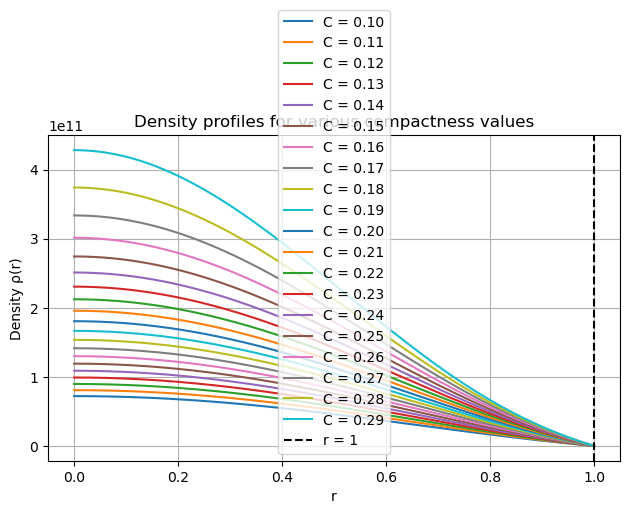

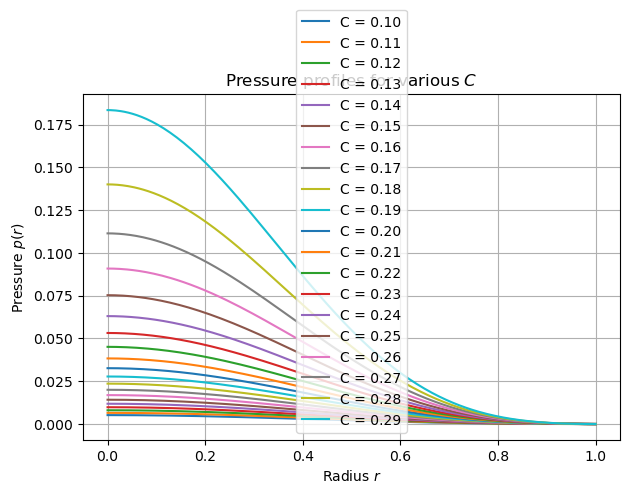

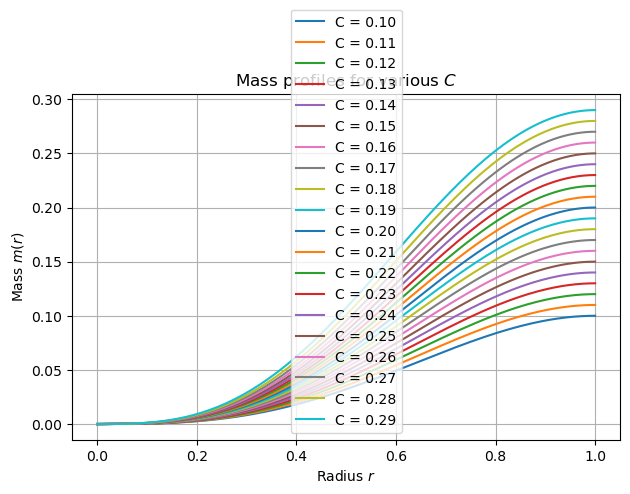

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline
import matplotlib.pyplot as plt

# Constants
K = 1.0              # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)


def tov_rhs(r, y):
    p, m,_ = y
    if p <= 0.0:
        return [0.0, 0.0,0.0]
    rho = rho_from_p(p)
    dpdr = -(rho + p) * (m + 4 * np.pi * r**3 * p) / (r * (r - 2 * m))
    dmdr = 4 * np.pi * r**2 * rho
    dnudr = -2* dpdr/(rho+p)
    return [dpdr, dmdr,dnudr]

# Solve TOV for a given p0
def solve_tov(p0):
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 5.0],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]

    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= 0:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (0 - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (0 - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.30, 0.01), 2)
profiles = {}

for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)
    """
    # Interpolate full solution on new scaled r grid
    r_vals = sol.t * scale_factor
    p_vals = sol.y[0]*scale_factor**2

    m_vals = sol.y[1] * scale_factor
    rho_vals = rho_from_p(p_vals)
    """
    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    mask = p_vals > 0
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    #print(np.min(r_vals))
    # after you have scaled/truncated and have:
    # === Normalize nu(r) to match exterior Schwarzschild metric ===
    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu

    # Optional: check that the matching condition is satisfied
    #print(f"C = {C_target:.2f} | nu_surface (raw) = {nu_raw_surface:.6f}, "f"target = {nu_target_surface:.6f}, shift = {delta_nu:.6f}")

    profiles[C_target] = {
        'r': r_vals,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

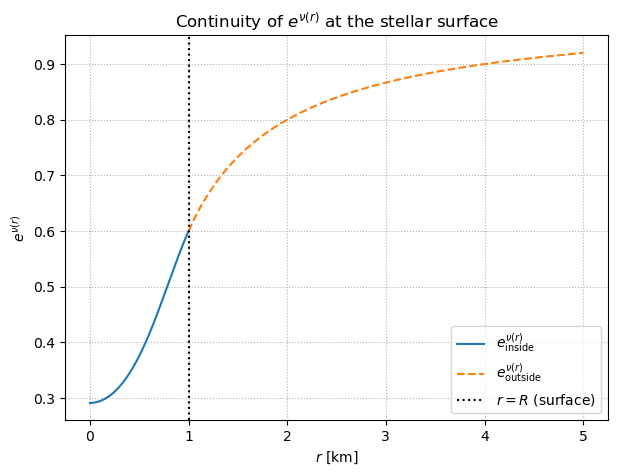

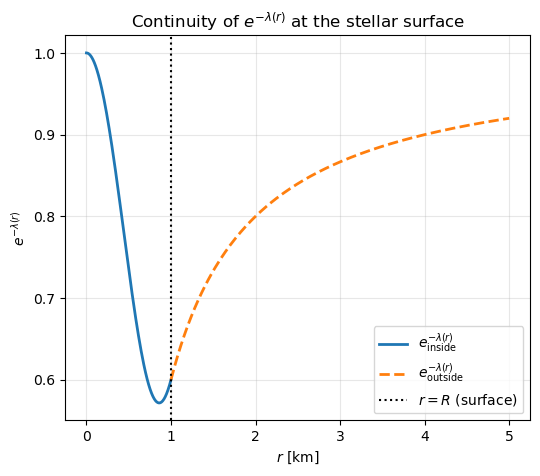

In [2]:
import numpy as np
import matplotlib.pyplot as plt
C = 0.2

M = profiles[C]['M']
R = profiles[C]['R']
nu_in = profiles[C]['nu_vals_norm']
r_in = profiles[C]['r']
m = profiles[C]['m']

def nu_out(r):
    return np.log(1 - 2*M/r)


exp_nu_in = np.exp(nu_in)
r_out = np.linspace(R, 5*R, 200)
exp_nu_out = np.exp(nu_out(r_out))


plt.figure(figsize=(7,5))
plt.plot(r_in, exp_nu_in, label=r'$e^{\nu(r)}_{\mathrm{inside}}$', color='tab:blue')
plt.plot(r_out, exp_nu_out, label=r'$e^{\nu(r)}_{\mathrm{outside}}$', color='tab:orange', linestyle='--')

plt.axvline(R, color='k', linestyle=':', label=r'$r=R$ (surface)')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$e^{\nu(r)}$')
plt.title('Continuity of $e^{\\nu(r)}$ at the stellar surface')
plt.legend()
plt.grid(True, ls=':')
plt.show()


elam_inside = 1 - 2 * m / r_in

r_out = np.linspace(R, 5 * R, 200)
elam_outside = 1 - 2 * M / r_out

plt.figure(figsize=(6,5))
plt.plot(r_in, elam_inside, label=r"$e^{-\lambda(r)}_{\rm inside}$", lw=2)
plt.plot(r_out, elam_outside, '--', label=r"$e^{-\lambda(r)}_{\rm outside}$", lw=2)
plt.axvline(R, color='k', ls=':', label=r"$r = R$ (surface)")
plt.xlabel(r"$r$ [km]")
plt.ylabel(r"$e^{-\lambda(r)}$")
plt.title(r"Continuity of $e^{-\lambda(r)}$ at the stellar surface")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# RW Interior

In [3]:
import numpy as np
import cmath as cm
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d

In [4]:
class ComplexSpline:
    def __init__(self, x, y, k=3):
        self.real_spline = CubicSpline(x, np.real(y))
        self.imag_spline = CubicSpline(x, np.imag(y))

    def __call__(self, x):
        return self.real_spline(x) + 1j * self.imag_spline(x)

    def derivative(self, n=1):
        der_real = self.real_spline.derivative(n)
        der_imag = self.imag_spline.derivative(n)
        return lambda x: der_real(x) + 1j * der_imag(x)


In [ ]:
def make_bg_splines(profile):
    r = profile['r']
    m = profile['m']
    p = profile['p']
    rho = profile['rho']
    nu = profile['nu_vals_norm']
    return {
        'r': r,
        'm_spline': CubicSpline(r,m),
        'p_spline': CubicSpline(r,p),
        'rho_spline': CubicSpline(r,rho),
        'nu_spline': CubicSpline(r, nu),
    }

def lambda_of_r(r, m):
    return -np.log(1.0 - 2.0 * m / r)

def rw_coeffs_r(r, bg, omega, l):

    m = bg['m_spline'](r)
    p = bg['p_spline'](r)
    rho = bg['rho_spline'](r)
    nu = bg['nu_spline'](r)

    # lambda and derivatives
    lam = lambda_of_r(r, m)
    #nu_prime = bg['nu_spline'].derivative()(r)
    #mprime = bg['m_spline'].derivative()(r)


    denom = 1.0 - 2.0 * m / r
    # first-derivative coefficient: C1 = (nu' -- lambda')/2
    C1 = (2.0* m / r**2 - (4*np.pi*r *(rho - p)))/denom

    # W(r) = l(l+1)/r^2 - 6 m / r^3 + 4π(ρ - p)


    # C0 = e^{lambda - nu} * (omega^2 - e^{nu} W)
    C0 = ((np.power(omega, 2.0) / cm.exp(nu)) - ((6.0 / np.power(r, 2.0)) * (1.0 - (m / r))) - (4.0 * np.pi * (rho - p)))/denom

    return C1, C0

def rw_interior_rhs(r, y, bg, omega, l):

    Re_psi, Re_psip, Im_psi, Im_psip = y
    psi = Re_psi + 1j * Im_psi
    psip = Re_psip + 1j * Im_psip

    C1, C0 = rw_coeffs_r(r, bg, omega, l)
    psipp = -C1 * psip - C0 * psi

    return [psip.real, psipp.real, psip.imag, psipp.imag]

def interior_ic_frobenius(r0, l, omega, rho_c, p_c, nu_c, normalize=True):
    """
    Frobenius expansion psi = r^{l+1} (1 + a r^2 + O(r^4)).
    """
    # coefficient alpha1 = coefficient of r in alpha(r) = (nu' - lambda')/2 ~ alpha1 * r + ...
    # previously derived: alpha1 = 2π (p_c - rho_c / 3)
    #alpha1 = 2.0 * np.pi * (p_c - rho_c / 3.0)

    #b0 = (omega**2) / np.exp(nu_c) + 4.0 * np.pi * (rho_c + p_c)

    #a = (cm.exp(nu_c) * omega**2 + (8 *np.pi *(2*r0 *p_c + 2*rho_c - 3*r0*rho_c)/r0)) * (-1/14)

    #psi = r0**(l + 1) * (1.0 + a * r0**2)
    #psi_prime = (l + 1) * r0**l + a * (l + 3) * r0**(l + 2)

    psi = r0**3 + (1/6) * cm.exp(-nu_c) * r0**5 *(omega**2 + 16*cm.exp(nu_c)*cm.pi*(p_c - rho_c))

    psi_prime = 3*r0**2 + (5/6)* cm.exp(-nu_c) * r0**4 *(omega**2 + 16*cm.exp(nu_c)*cm.pi*(p_c - rho_c))
    if normalize:
        scale = 1.0 / psi
        psi *= scale
        psi_prime *= scale

    return [psi.real, psi_prime.real, psi.imag, psi_prime.imag]



def integrate_rw_interior(profile, omega, l=2, r0=1e-6, rtol=1e-9, atol=1e-12):

    bg = make_bg_splines(profile)
    R = profile['R']
    # central values
    rho_c = profile['rho'][0]
    p_c = profile['p'][0]
    nu_c = profile['nu'][0]
    #print("rho_c:", rho_c, "p_c:", p_c, "nu_c:", nu_c )
    # initial conditions at r0
    y0 = interior_ic_frobenius(r0, l, omega, rho_c, p_c, nu_c, normalize=False)
    #print("y0:", y0)
    sol = solve_ivp(lambda r, y: rw_interior_rhs(r, y, bg, omega, l),
                    [r0, R], y0, method='RK45', atol=atol, rtol=rtol, max_step=(R - r0)/1000.0)

    if not sol.success:
        raise RuntimeError("Interior RW integration failed: " + str(sol.message))

    Re_psi = sol.y[0, :]
    Re_psip = sol.y[1, :]
    Im_psi = sol.y[2, :]
    Im_psip = sol.y[3, :]
    psi = Re_psi + 1j * Im_psi
    psip = Re_psip + 1j * Im_psip

    return {
        'r': sol.t,
        'psi': psi,
        'psip': psip,
        'R': R,
        'success': sol.success
    }




In [ ]:
C_target = 0.2
profile = profiles[C_target]
l = 2
omega_trial = 0.5

interior_sol = integrate_rw_interior(profile, omega_trial, l=l, r0=1e-6)

print("Interior integration success:", interior_sol['success'])
print("Number of interior grid points:", len(interior_sol['r']))
print("Psi(R) =", interior_sol['psi'][-1])
print("Psi'(R) =", interior_sol['psip'][-1])


Interior integration success: True
Number of interior grid points: 1076
Psi(R) = (1.3560448176918019+0j)
Psi'(R) = (4.247968869396839+0j)


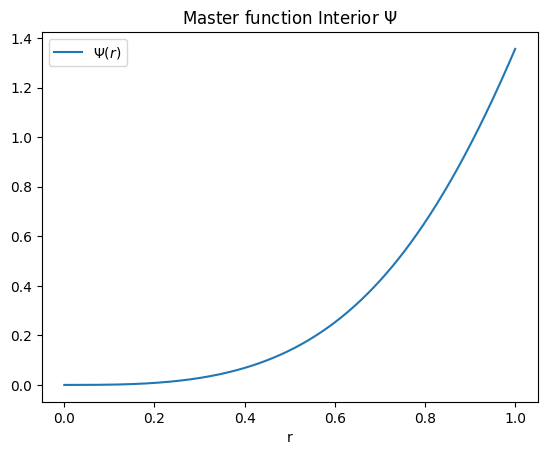

In [ ]:
plt.plot(interior_sol['r'], interior_sol['psi'].real, label=r'$\Psi(r)$')
#plt.plot(interior_sol['r'], 0.1*(h0.imag), label=r'$h0(r)$')
plt.title(r'Master function Interior $\Psi$')
plt.xlabel('r')
plt.legend()


# Intermediate R -> r_m

In [ ]:
def integrate_outward_from_R_non_visc(profile, interior_sol, omega, l, r_match, rtol=1e-10, atol=1e-12):
    R = profile['R']; M = profile['M']
    # take last interior values at R
    psi_R = interior_sol['psi'][-1]#complex(interior_sol['psi0spline'](R) + interior_sol['psi1spline'](R))
    dpsi_R = interior_sol['psip'][-1]#complex(interior_sol['psi0p_spline'](R) + interior_sol['psi1p_spline'](R))

    def RW_rhs(r, y):
        psi, dpsi = y
        f = 1.0 - 2.0*M/r
        V = f*(l*(l+1)/r**2 - 6.0*M/r**3)
        d2psi = -(2.0*M/r**2)/f * dpsi - ((omega**2 - V)/f**2) * psi
        return [dpsi, d2psi]

    if r_match <= R:
        raise ValueError("r_match must be > R")

    sol = solve_ivp(RW_rhs, [R, r_match], [psi_R, dpsi_R],
                    method='RK45', rtol=rtol, atol=atol, dense_output=True)
    if not sol.success:
        raise RuntimeError("Outward-from-R integration failed: " + sol.message)
    return sol.sol  # callable solution on [R, r_match]


In [ ]:
def integrate_outward_from_R(profile, interior_sol, omega, l, r_match, rtol=1e-10, atol=1e-12):
    R = profile['R']; M = profile['M']
    # take last interior values at R
    psi_R = complex(interior_sol['psi0spline'](R) + interior_sol['psi1spline'](R))
    dpsi_R = complex(interior_sol['psi0p_spline'](R) + interior_sol['psi1p_spline'](R))

    def RW_rhs(r, y):
        psi, dpsi = y
        f = 1.0 - 2.0*M/r
        V = f*(l*(l+1)/r**2 - 6.0*M/r**3)
        d2psi = -(2.0*M/r**2)/f * dpsi - ((omega**2 - V)/f**2) * psi
        return [dpsi, d2psi]

    if r_match <= R:
        raise ValueError("r_match must be > R")

    sol = solve_ivp(RW_rhs, [R, r_match], [psi_R, dpsi_R],
                    method='RK45', rtol=rtol, atol=atol, dense_output=True)
    if not sol.success:
        raise RuntimeError("Outward-from-R integration failed: " + sol.message)
    return sol.sol  # callable solution on [R, r_match]


# Exterior RW from infinity

In [ ]:
def rstar(r, M):
    return r + 2.0*M*np.log(r/(2.0*M) - 1.0)

def f_of_r(r, M):
    return 1.0 - 2.0*M/r

def A_coeffs_l2(M, omega, order=14):

    A = {0: 1.0 + 0j}

    if order >= 1:
        A[1] = (3j) / omega
    if order >= 2:
        A[2] = -((6 + 3j * M * omega) / (2 * omega**2))
    if order >= 3:
        A[3] = 0.0 + 0j
    if order >= 4:
        A[4] = (15 * M * (-2j + M * omega)) / (8 * omega**3)
    if order >= 5:
        A[5] = -((21j * M * (-2j + M * omega)) / (8 * omega**4))
    if order >= 6:
        A[6] = (21 * M * (8j + 6 * M * omega + 5j * M**2 * omega**2)) / (16 * omega**5)
    if order >= 7:
        A[7] = (3 * M * (72 - 118j * M * omega + 77 * M**2 * omega**2)) / (8 * omega**6)
    if order >= 8:
        A[8] = -((15 * M * (720j + 1684 * M * omega + 392j * M**2 * omega**2 + 315 * M**3 * omega**3)) / (128 * omega**7))
    if order >= 9:
        A[9] = (5 * M * (-7920 + 23132j * M * omega + 3240 * M**2 * omega**2 + 8393j * M**3 * omega**3)) / (128 * omega**8)
    if order >= 10:
        A[10] = (21 * M * (15840j + 54184 * M * omega - 25004j * M**2 * omega**2 + 21098 * M**3 * omega**3 - 3465j * M**4 * omega**4)) / (256 * omega**9)
    if order >= 11:
        A[11] = -((3 * M * (-1441440 + 5564344j * M * omega + 4125924 * M**2 * omega**2 + 1660718j * M**3 * omega**3 + 986755 * M**4 * omega**4)) / (704 * omega**10))
    if order >= 12:
        A[12] = (63 * M * (-5765760j - 24522496 * M * omega + 24252008j * M**2 * omega**2 - 3067300 * M**3 * omega**3 + 6964034j * M**4 * omega**4 + 495495 * M**5 * omega**5)) / (11264 * omega**11)
    if order >= 13:
        A[13] = (105 * M * (-259459200 + 1195764480j * M * omega + 1447458376 * M**2 * omega**2 - 126030636j * M**3 * omega**3 + 419667482 * M**4 * omega**4 - 85449595j * M**5 * omega**5)) / (146432 * omega**12)
    if order >= 14:
        A[14] = (15 * M * (2075673600j + 10240709760 * M * omega - 14448799040j * M**2 * omega**2 - 3845730024 * M**3 * omega**3 - 3716213956j * M**4 * omega**4 - 1498388738 * M**5 * omega**5 + 57972915j * M**6 * omega**6)) / (26624 * omega**13)

    return {k: A[k] for k in range(0, order + 1)}

def psi_series_and_derivative(r, M, omega, A):
    """
    Psi(r) = e^{i ω r_*} S(r), with S(r) = Σ A_k / r^k.
    Psi'(r) = e^{i ω r_*} [ (i ω / f) S + S' ] where f=1-2M/r and S' = dS/dr.
    """
    r = float(r)
    f = f_of_r(r, M)
    S = 0.0+0.0j
    dS = 0.0+0.0j
    for k, Ak in A.items():
        S  += Ak / (r**k)
        if k > 0:
            dS -= k * Ak / (r**(k+1))
    phase = np.exp(1j*omega*rstar(r, M))
    psi  = phase * S
    dpsi = phase * ((1j*omega/f)*S + dS)
    return psi, dpsi

def integrate_from_infinity_series(omega, l, M, r_match, r_max, order=4,
                                   rtol=1e-10, atol=1e-10, method='BDF'):

    if r_max <= 2.0*M:
        raise ValueError("r_max must satisfy r_max > 2M.")
    if l != 2:
        raise ValueError("This helper currently hard-codes l=2 series coefficients.")

    # ICs from series
    A = A_coeffs_l2(M, omega, order=order)
    psi0, dpsi0 = psi_series_and_derivative(r_max, M, omega, A)

    # RW ODE in r (vacuum)
    def RW_rhs(r, y):
        psi, dpsi = y
        f = f_of_r(r, M)
        V = f*(l*(l+1)/r**2 - 6.0*M/r**3)
        d2psi = -(2.0*M/r**2)/f * dpsi - ((omega**2 - V)/f**2) * psi
        return [dpsi, d2psi]

    sol = solve_ivp(RW_rhs, [r_max, r_match], [psi0, dpsi0],
                    method=method, rtol=rtol, atol=atol, dense_output=True)
    if not sol.success:
        raise RuntimeError(f"Exterior integration failed: {sol.message}")
    return sol.sol  # callable on [r_match, r_max]

In [ ]:
L[h00] = 0;
L[h01] = 0;

In [ ]:
h0 = h00

In [ ]:
h0 = h00 + k * h01

{0: (1+0j),
 1: 6j,
 2: (-12-0.6000000000001486j),
 3: 0j,
 4: np.complex128(0.30000000000014865-6.000000000001487j)}

In [ ]:
A = A_coeffs_l2(profile['M'], 0.87-0.5j, order=4)

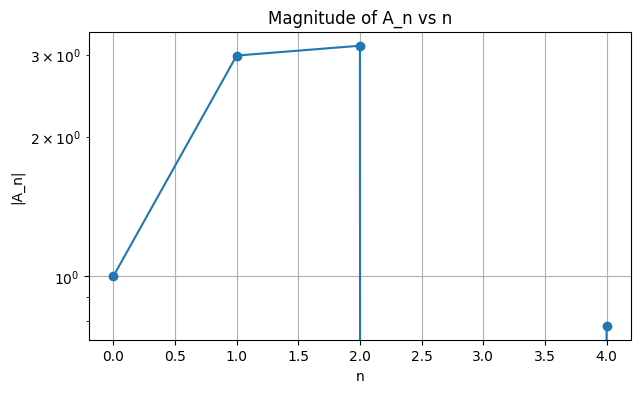

In [ ]:
n_vals = np.array(sorted(A.keys()))
A_vals = np.array([A[n] for n in n_vals])  # complex numbers

magnitudes = np.abs(A_vals)

plt.figure(figsize=(7,4))
plt.plot(n_vals, magnitudes, marker='o')
plt.yscale('log')              # convergence patterns usually need log-scale
plt.xlabel("n")
plt.ylabel("|A_n|")
plt.title("Magnitude of A_n vs n")
plt.grid(True)
plt.show()


In [ ]:
psi_series_and_derivative(30, profile['M'], omega_trial, A_coeffs_l2(profile['M'], omega_trial, order=14))

(np.complex128(-0.94481459212276-0.34722723434968983j),
 np.complex128(0.17407304158310236-0.47238247553818713j))

In [ ]:
psi_series_and_derivative(30, profile['M'], omega_trial,A_coeffs_l2(profile['M'], omega_trial, 4))

(np.complex128(-0.944815262253938-0.3472272842587345j),
 np.complex128(0.17407317784613263-0.4723828096031353j))

In [ ]:
#e^(i omega r*) *Sum[ A[]/r]

In [ ]:
C_target = 0.2
profile = profiles[C_target]
l = 2
omega_trial = 0.5

M = profile['M']
r_m = 4 * profile['R']
r_max = 30#150 * profile['M']   # large enough for clean asymptotics

ext_sol = integrate_from_infinity_series(omega_trial, l, M, r_m, r_max)

# Evaluate at matching radius:
psi_ext_rm, dpsi_ext_rm = ext_sol(r_m)

In [ ]:
print(psi_ext_rm, dpsi_ext_rm)
del psi_ext_rm, dpsi_ext_rm

(-1.117978082510115-0.9467398415061743j) (0.4526874259225347-0.11357920609567236j)


# Playground

In [ ]:
C_target = 0.2
profile = profiles[C_target]
l = 2
omega_trial = 0.5

M = profile['M']
r0 = 1e-6
r_m = 4 * profile['R']
r_max = 150 * profile['M']   # large enough for clean asymptotics

interior_sol = integrate_rw_interior(profile, omega_trial, l=l, r0=1e-6)
interim_sol = integrate_outward_from_R(profile, interior_sol, omega_trial, l, r_m)
ext_sol = integrate_from_infinity_series(omega_trial, l, M, r_m, r_max, order=14)

In [ ]:
scaling = interim_sol(r_m)[0]/ext_sol(r_m)[0]

In [ ]:
ext_psi_scaled = lambda r: ext_sol(r)[0] * scaling
ext_dpsi_scaled = lambda r: ext_sol(r)[1] * scaling

In [ ]:
ext_psi_scaled(r_m)

np.complex128(62.735015717683005+0j)

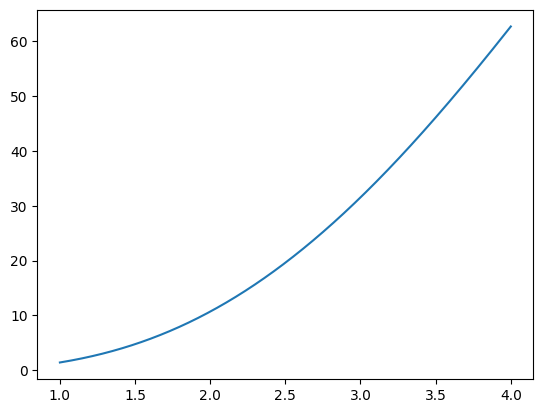

In [ ]:
rtestinterim = np.linspace(1, r_m, 1000)

plt.plot(rtestinterim, np.abs(interim_sol(rtestinterim)[0]))

In [ ]:
interim_sol(1)[0]

np.complex128(1.4127892628781948+0j)

In [ ]:
interior_sol['psi']

array([9.99999351e-19+0.j, 3.37498914e-18+0.j, 3.74944712e-17+0.j, ...,
       1.40517755e+00+0.j, 1.40969204e+00+0.j, 1.41278926e+00+0.j])

Text(0.5, 0, '$r$')

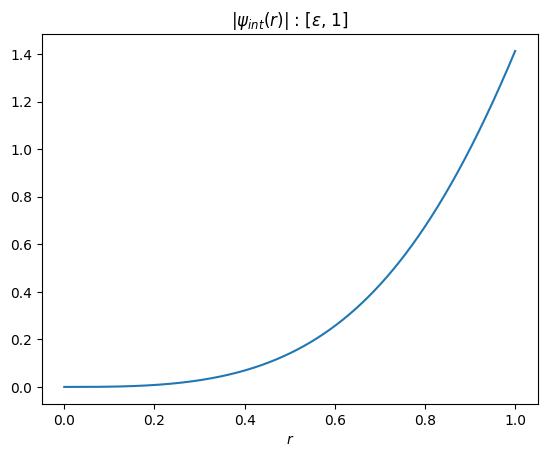

In [ ]:
plt.title(r'$|\psi_{int} (r)|$ : [$\epsilon$, $1$]')
plt.plot(interior_sol['r'], interior_sol['psi'].real)
plt.xlabel(r'$r$')

Text(0.5, 0, '$r$')

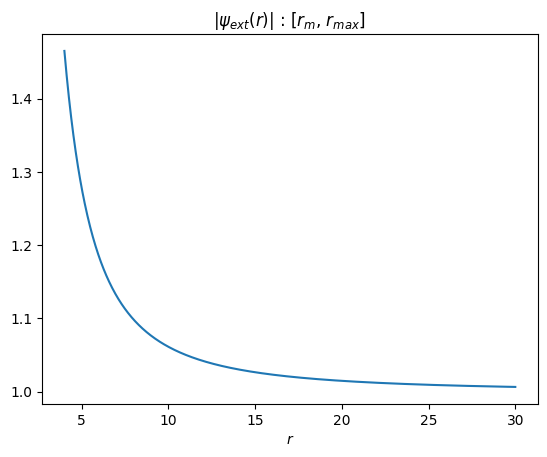

In [ ]:
rtest = np.linspace(r_m, r_max, 1000)
plt.title(r'$|\psi_{ext} (r)|$ : [$r_{m}$, $r_{max}$]')
plt.plot(rtest, np.abs(ext_sol(rtest)[0]))
plt.xlabel(r'$r$')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_full_solution(profile, interior_sol, out_sol, ext_sol,
                       omega, r_m, r_max, n1=400, n2=400, n3=400, plot_abs=True):

    R = profile['R']
    M = profile['M']

    # --- Interior values are discrete arrays
    r_int = interior_sol['r']
    psi_int = interior_sol['psi0spline'](r_int) + interior_sol['psi1spline'](r_int)

    # --- Outward vacuum solution on [R, r_m]
    r_out = np.linspace(R, r_m, n2)
    psi_out = np.array([out_sol(r)[0] for r in r_out], dtype=complex)

    # --- Inward vacuum solution on [r_m, r_max]
    r_ext = np.linspace(r_m, r_max, n3)
    psi_ext_raw = np.array([ext_sol(r)[0] for r in r_ext], dtype=complex)

    # --- Match amplitudes at r_m
    psi_out_rm = out_sol(r_m)[0]
    psi_ext_rm = ext_sol(r_m)[0]
    C = psi_out_rm / psi_ext_rm
    psi_ext = C * psi_ext_raw

    # --- Combine domains
    r_full = np.concatenate([r_int, r_out, r_ext])
    psi_full = np.concatenate([psi_int, psi_out, psi_ext])

    # --- Plot
    plt.figure(figsize=(9,6))
    if plot_abs:
        plt.plot(r_full, np.abs(psi_full), label=r'$|\Psi(r)|$')
        plt.ylabel(r'$|\Psi(r)|$')
    else:
        plt.plot(r_full, psi_full.real, label='Re Ψ')
        plt.plot(r_full, psi_full.imag, label='Im Ψ')
        plt.ylabel('Ψ(r)')

    # Mark R and matching radius
    plt.axvline(R, linestyle=':', color='k', alpha=0.5)
    plt.axvline(r_m, linestyle='--', color='k', alpha=0.6)

    plt.xlabel('r')
    plt.title(f"Full matched solution |Ψ(r)|, ω = {omega}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return r_full, psi_full


In [ ]:
omega_trial

0.5

In [ ]:
omega_trial = 0.9 - 0.6j
r_m = 1.01
r_max = 30


interior_sol = interior_solution(omega_trial, 1e-8)
interim_sol = integrate_outward_from_R(profile, interior_sol, omega_trial, 2, r_m)
ext_sol = integrate_from_infinity_series(omega_trial, 2, profile['M'], r_m, r_max)

In [ ]:
A_coeffs_l2(profile['M'], omega_trial, order=4)

{0: (1+0j),
 1: (-1.5384615384615383+2.3076923076923075j),
 2: (-0.8323471400394096-2.5976331360947316j),
 3: 0j,
 4: np.complex128(0.6062560056644462+0.1729631315430707j)}

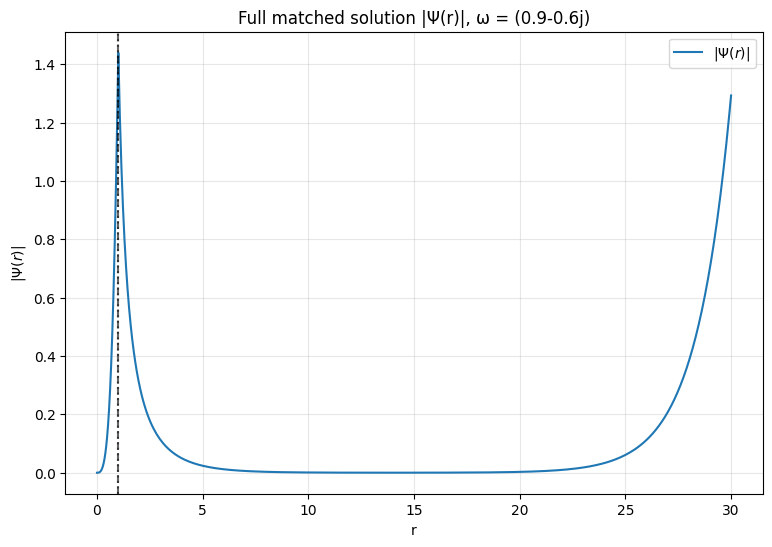

(array([1.00000000e-06, 8.35027523e-04, 1.66905505e-03, ...,
        2.98546867e+01, 2.99273434e+01, 3.00000000e+01]),
 array([ 1.00000000e-18-1.79963168e-31j,  5.79487075e-10+3.11789792e-17j,
         4.62757919e-09+9.94772130e-16j, ...,
        -9.11587591e-01-7.54476948e-01j, -8.98724741e-01-8.49861474e-01j,
        -8.78723612e-01-9.48458658e-01j]))

In [ ]:
plot_full_solution(profile, interior_sol, interim_sol, ext_sol, omega_trial, r_m, r_max)

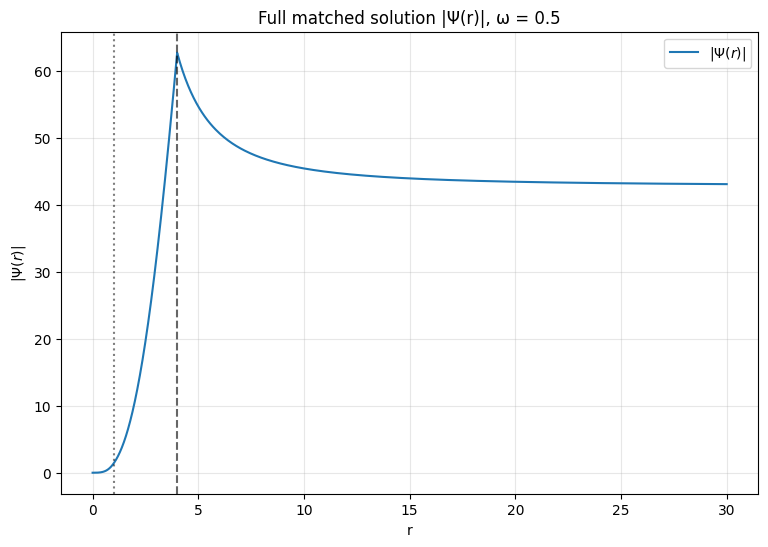

(array([1.00000000e-06, 1.49999978e-06, 3.35028924e-06, ...,
        2.98696742e+01, 2.99348371e+01, 3.00000000e+01]),
 array([9.99999351e-19 +0.j        , 3.37498914e-18 +0.j        ,
        3.74944712e-17 +0.j        , ..., 3.94375834e+01-17.40610721j,
        3.99826383e+01-16.11140401j, 4.04852249e+01-14.79963245j]))

In [ ]:
plot_full_solution(profile, interior_sol, interim_sol, ext_sol, omega_trial, r_m, r_max)

# QNM computations

In [ ]:
from tqdm import tqdm
del interior_sol, interim_sol, ext_sol

NameError: name 'interior_sol' is not defined

In [ ]:
C_target = 0.2
profile = profiles[C_target]
l = 2
omega_trial = 0.65 - 0.17j

M = profile['M']
r0 = 1e-6
r_m = 1.01 #4 * profile['R']
r_max = 150 * profile['M']

In [ ]:
def wronskian(profile, omega, l, r_m, r_max, r0=1e-6, order=4):

  R, M = profile['R'], profile['M']

  int_sol = integrate_rw_interior(profile, omega, l=l, r0=r0)
  inter_sol = integrate_outward_from_R_non_visc(profile, int_sol, omega, l, r_m)
  ext_sol = integrate_from_infinity_series(omega, l, M, r_m, r_max, order=order)

  psi_in_rm, dpsi_in_rm = inter_sol(r_m)
  psi_out_rm, dpsi_out_rm = ext_sol(r_m)

  W = (psi_out_rm * dpsi_in_rm - psi_in_rm * dpsi_out_rm)
  return W


In [ ]:
wronskian(profile, omega_trial, 2, r_m, r_max)

np.complex128(-24.100086294765525-44.012528695685916j)

In [ ]:
wronskian(profile, omega_trial, 2, r_m, r_max, order=4)

np.complex128(-28.566384627248567-46.53558665792684j)

In [ ]:
def scan_param(profile, l, re_range, im_range, r_m, r_max, r0=1e-6):
  Re = np.linspace(*re_range)
  Im = np.linspace(*im_range)

  heat = np.empty((len(Re), len(Im)))

  for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
    for j, im in enumerate(Im):
      om = re + 1j * im
      W = wronskian(profile, om, l, r_m, r_max, r0=r0)
      heat[i, j] = np.log10(max(1e-30, abs(W)))

  return Re, Im, heat


Scanning Re(ω): 100%|██████████| 80/80 [1:21:07<00:00, 60.84s/it]


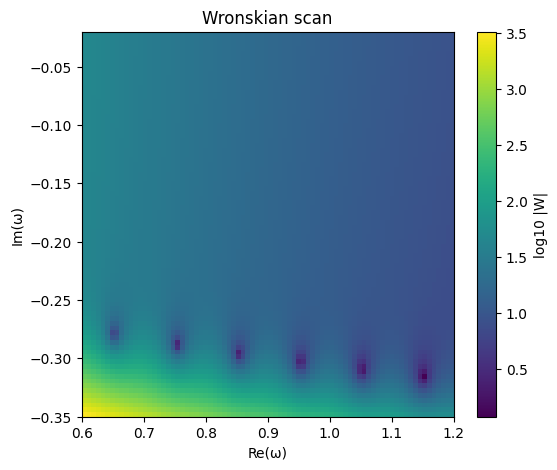

In [ ]:

Re, Im, heat = scan_param(profile, l=2, re_range=(0.6, 1.2, 80),im_range=(-0.35, -0.02, 80),r_m=4.0, r_max=r_max)

plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('Wronskian scan')
plt.show()


In [ ]:
r_max = 30

np.float64(30.000000000007432)

Scanning Re(ω): 100%|██████████| 80/80 [1:22:06<00:00, 61.59s/it]


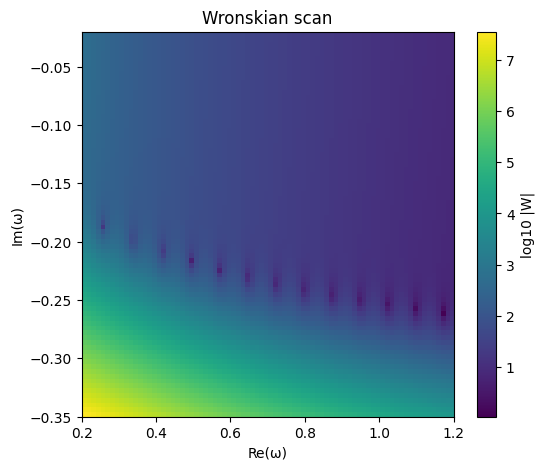

In [ ]:

Re, Im, heat = scan_param(profile, l=2, re_range=(0.2, 1.2, 80),im_range=(-0.35, -0.02, 80),r_m=4.0, r_max=r_max)

plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('Wronskian scan')
plt.show()


In [ ]:
r_max

30

Scanning Re(ω): 100%|██████████| 100/100 [1:21:57<00:00, 49.18s/it]


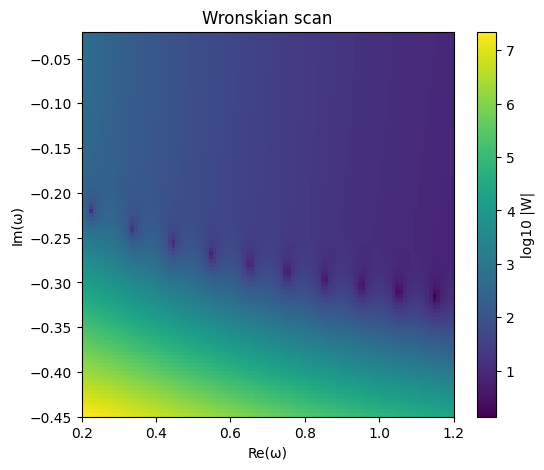

In [ ]:
# Run the above code again for order=14
import matplotlib.pyplot as plt

Re, Im, heat = scan_param(profile, l=2, re_range=(0.2, 1.2, 100),im_range=(-0.45, -0.02, 100),r_m=r_m, r_max=r_max)

plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('Wronskian scan')
plt.show()


In [ ]:
from scipy.optimize import root
def find_qnm_wronskian(profile, l, omega_guess, r_m, r_max, r0= 1e-6, tol=1e-10, maxfev=300, order=4):
  def F(xy):
    om = xy[0] + 1j * xy[1]
    W = wronskian(profile, om, l, r_m, r_max, r0=r0,order=order)
    return np.array([W.real, W.imag])

  x0 = np.array([omega_guess.real, omega_guess.imag],float)
  sol = root(F,x0, method='lm', tol=tol)
  if not sol.success:
    raise RuntimeError(f"QNM wronskian scan failed: {sol.message}")
  om_star = sol.x[0] + 1j* sol.x[1]
  Wf = wronskian(profile, om_star, l, r_m, r_max, r0=r0, order=order)

  info = {'success':bool(sol.success), 'message': sol.message, 'nfev': sol.nfev, 'qnm': om_star, 'W': Wf, 'abs(W)': np.abs(Wf)}
  print(f"success={info['success']} message={info['message']}")
  print(f"ω* = {om_star:.12g}  |W| = {abs(Wf):.3e}  at r_m={r_m}, r_max={r_max:.3g}")

  return om_star, info



In [ ]:
250*profile['M']

np.float64(50.00000000001239)

In [ ]:
omega_guess = 0.2-0.2j

qnmw0 = {}

for i in [1.01,1.03,1.05]:
  for j in [30,40,50]:
    r_m = i
    r_max = j
    qnmw0[i,j] = find_qnm_wronskian(profile, l=2, omega_guess=omega_guess, r_m=r_m, r_max=r_max, order=4)





success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619411-0.219014442843j  |W| = 5.436e-08  at r_m=1.01, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.412079649902-0.208678907508j  |W| = 4.407e-07  at r_m=1.01, r_max=40
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.200402181563-0.15249138899j  |W| = 4.275e-07  at r_m=1.01, r_max=50
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.21988161941-0.219014442848j  |W| = 2.171e-08  at r_m=1.03, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.412079649884-0.208678907539j  |W| = 1.776e-06  at r_m=1.03, r_max=40
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.200402181563-0.152491388993j  |W| = 5.239e-07  at r_m=1.0

In [ ]:
omega_guess = 0.2-0.2j

qnmw0 = {}

for i in [1.01,1.03,1.05]:
  r_m = i
  qnmw0[i] = find_qnm_wronskian(profile, l=2, omega_guess=omega_guess, r_m=r_m, r_max=r_max, order=4)



success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.200402181563-0.15249138899j  |W| = 4.275e-07  at r_m=1.01, r_max=50
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.200402181563-0.152491388993j  |W| = 5.239e-07  at r_m=1.03, r_max=50
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.200402181554-0.152491388995j  |W| = 3.441e-07  at r_m=1.05, r_max=50


In [ ]:
(0.200402181563-0.15249138899j)*profile['M']

(0.04008043631260993-0.030498277798007557j)

Scanning Re(ω): 100%|██████████| 80/80 [1:44:22<00:00, 78.29s/it]


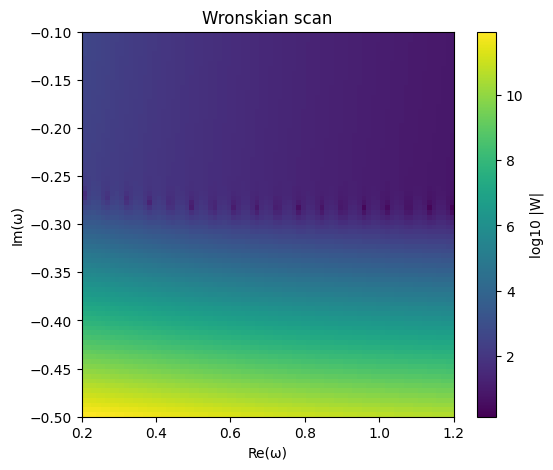

In [ ]:
# Run the above code again for order=14
import matplotlib.pyplot as plt

Re, Im, heat = scan_param(profile, l=2, re_range=(0.2, 1.2, 80),im_range=(-0.5, -0.1, 80),r_m=4.0, r_max=r_max)

plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('Wronskian scan')
plt.show()


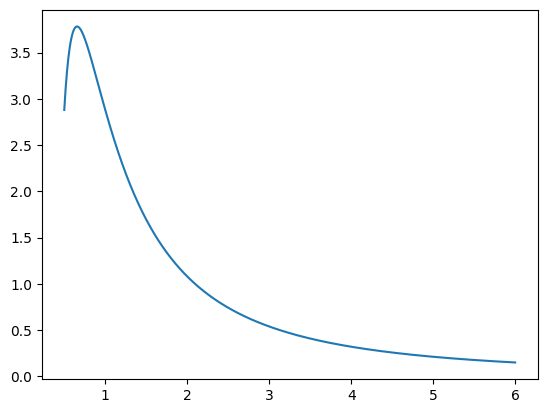

In [ ]:
def potential_RW(r, M):
    f = 1 - 2*M/r
    return f *( (6/r**2) - (6*M/r**3) )

M = 0.2
rtest = np.linspace(0.5,6, 1000)

plt.plot(rtest, potential_RW(rtest,M))

In [ ]:
r_max

np.float64(30.000000000007432)

In [ ]:
print(r_m, r_max)

1.01 30.000000000007432


In [ ]:
omega_guess = 0.7 - 0.35j

find_qnm_wronskian(profile, l, omega_guess, r_m, r_max)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.703297601499-0.348381879042j  |W| = 3.795e+01  at r_m=1.01, r_max=30


(np.complex128(0.7032976014990421-0.3483818790419744j),
 {'success': True,
  'message': 'The relative error between two consecutive iterates is at most 0.000000',
  'nfev': 38,
  'qnm': np.complex128(0.7032976014990421-0.3483818790419744j),
  'W': np.complex128(0.38078324686732445-37.94378633373121j),
  'abs(W)': np.float64(37.94569695263143)})

In [ ]:
import numpy as np
from tqdm import tqdm

def scan_param(profile, l, re_range, im_range, r_m, r_max, r0=1e-6):
    Re = np.linspace(*re_range)
    Im = np.linspace(*im_range)

    # heat_log[i,j]   = log10 |W|
    # W_abs[i,j]      = |W|
    heat_log = np.empty((len(Re), len(Im)))
    W_abs    = np.empty((len(Re), len(Im)))

    for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
        for j, im in enumerate(Im):
            om = re + 1j * im
            W = wronskian(profile, om, l, r_m, r_max, r0=r0)
            W_val = abs(W)
            W_abs[i, j] = W_val
            heat_log[i, j] = np.log10(max(W_val, 1e-30))

    return Re, Im, heat_log, W_abs

def find_global_minimum(Re, Im, W_abs):

    idx = np.unravel_index(np.argmin(W_abs), W_abs.shape)
    i_re, i_im = idx
    return (Re[i_re], Im[i_im]), W_abs[i_re, i_im]


def find_local_minima(Re, Im, W_abs):

    minima = []
    nr, ni = W_abs.shape

    for i in range(1, nr-1):
        for j in range(1, ni-1):
            val = W_abs[i, j]
            # extract 3×3 neighborhood
            neigh = W_abs[i-1:i+2, j-1:j+2]
            if np.all(val < neigh[np.where(~np.eye(3, dtype=bool))]):  # strictly less than all 8 neighbors
                minima.append((Re[i], Im[j], val))

    # Sort from smallest |W| to largest
    minima.sort(key=lambda x: x[2])
    return minima


In [ ]:
Re, Im, heat_log, W_abs = scan_param(profile, l,
                                     re_range=(0.2, 1.2, 100),
                                     im_range=(-0.5, -0.1, 100),
                                     r_m=1.01, r_max=30)

# Global minimum
(re_min, im_min), W_min = find_global_minimum(Re, Im, W_abs)
print("Global minimum:")
print("  ω =", re_min, "+", im_min, "i")
print("  |W| =", W_min)

# All local minima:
loc_mins = find_local_minima(Re, Im, W_abs)
print("Number of local minima found:", len(loc_mins))
print("Top 10 deepest minima:")
for x in loc_mins[:10]:
    print(f"  ω = {x[0]:.6f} + {x[1]:.6f}i,  |W| = {x[2]:.3e}")


Scanning Re(ω):  97%|█████████▋| 97/100 [2:06:49<04:18, 86.07s/it]

# Viscous terms included

In [ ]:
profile= profiles[0.2]
T = 1e5 #Temperature
Ke = 4e25 / (T/1e5)**2 #cgs g cm^-1 s^-1
G = 6.67e-8
c = 3e10
conv = G/c**3
R_n = 1e6 # 10 km
Ken = 1e-7*(1/10)#Ke*conv * R_n; #cgs -> geometric cm^-1  # Arbitrary here we can set this to any value elsewhere
eps = 1e-6
rho_sat =  2.8e14 #cgs
r_vals, m_spline, p_spline, rho_spline, nu_spline = make_bg_splines(profile).values()
rho_vals      = rho_spline(r_vals)
rho_cgs_vals  = rho_vals * 1.4e16
rho_cgs_spline = ComplexSpline(r_vals, rho_cgs_vals, k=3)

# Derivatives
rho_prime_spline  = rho_spline.derivative()
rho_2prime_spline = rho_spline.derivative(2)

rho_cgs_prime_spline  = rho_cgs_spline.derivative()
rho_cgs_2prime_spline = rho_cgs_spline.derivative(2)

nu_prime_spline = nu_spline.derivative()
p_prime_spline  = p_spline.derivative()

In [ ]:
def etaf(r, K): return K * (rho_cgs_spline(r)**2)/(rho_sat**2)
def eta_p(r, K): return K * rho_cgs_prime_spline(r) * 2 * rho_cgs_spline(r)/(rho_sat**2)
def eta_2p(r, K): return (2*K/rho_sat**2)*(rho_cgs_prime_spline(r)**2 + rho_cgs_spline(r)* rho_cgs_2prime_spline(r))

def elambda(r):
    m = m_spline(r)
    return 1.0 / (1.0 - 2 * m / r)

nu0 = nu_spline(eps)
p0 = p_spline(eps)
rho0 = rho_spline(eps)
lambd2 = 8*np.pi*rho0/3
elambd0 = elambda(eps)

def p2o(r):
    return -0.5*(p0+rho0) *4*np.pi*(p0 + (rho0/3))
def rho2o(r):
    return p2o(r)/(p_prime_spline(eps)/rho_prime_spline(eps))
def nu2o(r):
    return (4*np.pi/3)*(rho0+3*p0)

In [ ]:
r0_vals, psi0_vals = integrate_rw_interior(profile, omega_trial, l=2, r0=1e-6)
psi0_spline = ComplexSpline(r0_vals, psi0_vals)

In [ ]:
"""
def psi1_init(r, om):
  pi = cm.pi
  K = Ken/rho_sat**2
  const = cm.exp(-nu0) *((3*om**3 + 48 * cm.exp(nu0)*pi* om*(p0 - rho0) + 96j * cm.exp(nu0/2) * K * pi* om**2 *rho0**2 + 256j * cm.exp(3*nu0/2) * K * pi * rho0 * (3*p0 + rho0) + 3*rho2o(eps)))/18*om
  return const * r**5
def psi1p_init(r, om):
  pi = cm.pi
  K = Ken/rho_sat**2
  const = cm.exp(-nu0) *((3*om**3 + 48 * cm.exp(nu0)*pi* om*(p0 - rho0) + 96j * cm.exp(nu0/2) * K * pi* om**2 *rho0**2 + 256j * cm.exp(3*nu0/2) * K * pi * rho0 * (3*p0 + rho0) + 3*rho2o(eps)))/18*om
  return 5*r**4 *const
"""

In [ ]:
def psi1_init(r, om, K_visc):
  pi = cm.pi
  #K = K_visc/rho_sat**2
  eta = etaf(eps, K_visc)
  etap = eta_p(eps, K_visc)
  eta2p = eta_2p(eps, K_visc)
  const = cm.exp(-nu0) * (32j * cm.exp(nu0/2) * pi * (3*om**2 + 8*cm.exp(nu0)*pi *(3*p0 + rho0)) * eta + 3*(om**3 + 16*cm.exp(nu0)*pi*om*(p0-rho0) + 128j * cm.exp(3*nu0/2) * pi* rho2o(r) * etap))
  return r**3 + const * r**5  / (18*om)

def psi1p_init(r, om, K_visc):
  pi = cm.pi
  #K = K_visc/rho_sat**2
  eta = etaf(eps, K_visc)
  etap = eta_p(eps, K_visc)
  eta2p = eta_2p(eps, K_visc)

  const = cm.exp(-nu0) * (32j * cm.exp(nu0/2) * pi * (3*om**2 + 8*cm.exp(nu0)*pi *(3*p0 + rho0)) * eta + 3*(om**3 + 16*cm.exp(nu0)*pi*om*(p0-rho0) + 128j * cm.exp(3*nu0/2) * pi* rho2o(r) * etap))

  return 3*r**2 + 5*r**4 *const / (18*om)

In [ ]:
def psi1pp(r, y, om, psi0, K_visc):
  pi = np.pi
  psi1_re, psi1_im, psi1_p_re, psi1_p_im = y
  psi0p = psi0.derivative()
  psi02p = psi0.derivative(2)
  psi1 = psi1_re + 1j*psi1_im
  psi1_prime = psi1_p_re + 1j*psi1_p_im
  rho = rho_spline(r)
  p = p_spline(r)
  rhop = rho_prime_spline(r)
  rho2p = rho_2prime_spline(r)
  m = m_spline(r)
  el = elambda(r)
  eta = etaf(r, K_visc)
  etap = eta_p(r, K_visc)
  eta2p = eta_2p(r, K_visc)
  nu = nu_spline(r)
  enu = cm.exp(nu_spline(r))
  enum = cm.exp(-nu_spline(r))

  rho_p = rho + p
  enuminus = 4*enu-r**2 *om**2
  enuplus = 4*enu + r**2 *om**2
  denom = 1.0 - 2.0 * m / r
  #psi1 coeff
  psi1coeff = (el*(6*r - enum*r**3 *om**2 - 6*m - 4*pi*r**3 *p + 4*pi*r**3 *rho))/r**3
  #psi1p coeff
  psi1pcoeff =  - (2.0* m / r**2 - (4*np.pi*r *(rho - p)))/denom

  #psi0 coeff
  psi0num = - 16j * cm.exp(3*nu/2) *pi * (eta * (80*enu**2 + 16*el**2 *enu**2 - 96*el*enu**2 - 40*enu*r**2 *om**2 - 8*el**2 *enu *r**2 *om**2 + 77*r**4 *om**4 - 62*el*r**4 *om**4 + 9*el**2 *r**4 * om**4 + 16*el*pi*r**2 *(16* el*enu**2 - 16*enu*r**2 *om**2 - 8*el*enu *r**2 *om**2 -20*r**4 *om**4 + 9*el*r**4 *om**4)*p + 64*el**2 *pi**2 *r**4 *(16*enu**2 - 8*enu*r**2 *om**2 + 9*r**4 *om**4)*p**2 + 16*el*pi*r**2 *(16*enu**2 - 24*enu*r**2 *om**2 + 5*r**4 *om**4)* rho) + 4*r*enuminus *(r*enuminus*rhop**2 * eta2p + etap*(4*(-2*enu + 2*el*enu + 2*r**2 *om**2 - el* r**2 *om**2 + el*pi*r**2 *(12*enu - 7*r**2 *om**2)*p + el*pi*r**2 *(-enuminus)*rho)*rhop + r*(enuminus)*rho2p)))
  psi0den = r**2 *om * (-enuminus)**3
  psi0coeff = psi0num/psi0den

  #psi0p coeff
  psi0pnum = 64j*cm.exp(3*nu/2)*pi *((-4*enu + 4*el*enu + 7*r**2 *om**2 - 3*el*r**2 *om**2 + 8*el*pi*r**2 *(4*enu - 3*r**2 *om**2)*p)*eta - 2*r*(-enuminus)*etap * rhop)
  psi0pden = r*om*(-enuminus)**2
  psi0pcoeff = psi0pnum/psi0pden

  psi1pp = psi1coeff * psi1 + psi1pcoeff * psi1_prime + psi0coeff * psi0(r) + psi0pcoeff * psi0p(r)

  return [psi1_p_re, psi1_p_im, psi1pp.real, psi1pp.imag]

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def compute_psi1_on_grid(profile, om, K_visc, eps=1e-6, Ngrid=1200, r_end=None):

    if r_end is None:
        r_end = profile['R']

    psi0_res = integrate_rw_interior(profile, om, l=2, r0=eps)
    r0_vals, psi0_vals = psi0_res['r'], psi0_res['psi']
    psi0_spline = ComplexSpline(r0_vals, psi0_vals)

    r_eval = np.linspace(eps, r_end, Ngrid)

    psi1_ic = psi1_init(eps, om, K_visc)
    psi1p_ic = psi1p_init(eps, om , K_visc)
    y0 = [psi1_ic.real, psi1_ic.imag, psi1p_ic.real, psi1p_ic.imag]

    def rhs(r, y):
        return psi1pp(r, y, om, psi0_spline, K_visc)

    sol = solve_ivp(rhs, [eps, r_end], y0, t_eval=r_eval, method='RK45', rtol=1e-9, atol=1e-12)

    if not sol.success:
        raise RuntimeError(f"psi1 integrator failed: {sol.message}")

    r = sol.t
    psi1_re = sol.y[0]
    psi1_im = sol.y[1]
    psi1p_re = sol.y[2]
    psi1p_im = sol.y[3]

    psi1 = psi1_re + 1j * psi1_im
    psi1p = psi1p_re + 1j * psi1p_im

    return r, psi1, psi1p, psi0_spline

def finite_diff_elimination_grid(profile, om, K_visc, delta=0.1, eps=1e-6, Ngrid=1200):

    delta = abs(delta)
    K1 = K_visc * (1.0 - delta)
    K2 = K_visc * (1.0 + delta)

    r1, pK1, pK1p, psi0_spline = compute_psi1_on_grid(profile, om, K1, eps=eps, Ngrid=Ngrid, r_end=profile['R'])
    r2, pK2, pK2p, _ = compute_psi1_on_grid(profile, om, K2, eps=eps, Ngrid=Ngrid, r_end=profile['R'])

    if not np.allclose(r1, r2):
        raise RuntimeError("r grids from fixed-grid solves differ unexpectedly.")
    r = r1

    dK = (K2 - K1)
    H = (pK2 - pK1) / dK
    H_hom_est = pK1 - K1 * H

    diagnostics = {
        "K1": K1, "K2": K2, "delta": delta,
        "max_hom": float(np.max(np.abs(H_hom_est))),
        "max_psi1_k1": float(np.max(np.abs(pK1))),
        "hom_fraction": float(np.max(np.abs(H_hom_est)) / (np.max(np.abs(pK1)) + 1e-30)),
        "grid_len": len(r),
    }

    return r, H, H_hom_est, diagnostics, psi0_spline


In [ ]:
def compute_psi0(om, eps=1e-6):
  res = integrate_rw_interior(profile, om, l=2, r0=eps)
  r0_vals, psi0_vals = res['r'], res['psi']
  return r0_vals, psi0_vals

def compute_psi1(om, K_visc, eps=1e-6):
  r0_vals, psi0_vals = compute_psi0(om, eps)
  psi0_spline = ComplexSpline(r0_vals, psi0_vals)

  y0 = [
      psi1_init(eps, om, K_visc).real,
      psi1_init(eps, om, K_visc).imag,
      psi1p_init(eps, om, K_visc).real,
      psi1p_init(eps, om, K_visc).imag
  ]

  sol_psi1 = solve_ivp(psi1pp, [eps, 1], y0, method = 'RK45', args=(om, psi0_spline, K_visc),rtol=1e-10, atol=1e-10)

  r = sol_psi1.t
  psi1_re, psi1_im, psi1p_re, psi1p_im = sol_psi1.y[:]
  psi1 = psi1_re + 1j*psi1_im
  psi1p = psi1p_re + 1j*psi1p_im

  return r, psi1, psi1p , psi0_spline

def fixK1K2(K_visc, delta):
  K1 = K_visc *(1 + delta)
  K2 = K_visc *(1 - delta)
  return K1, K2

def finite_diff_elimination(om, K_visc, delta = 0.1, eps=1e-6):

  K_1, K_2 = fixK1K2(K_visc, delta)

  r_pK1, pK1, _ , psi0_spline = compute_psi1(om, K_1, eps)
  r_pK2, pK2, _ , _= compute_psi1(om, K_2, eps)

  if not (r_pK1.shape==r_pK2.shape):
        interp = interp1d(r_pK2, pK2, kind='cubic', axis=0, fill_value="extrapolate")
        psi1_k2_on_r1 = interp(r_pK1)
        r = r_pK1
  else:
        psi1_k2_on_r1 = pK2
        r = r_pK1
  H = (psi1_k2_on_r1 - pK1) / (K_2 - K_1)
  H_hom_est = pK1 - K_1 * H

  diagnostics = {
        "K1": K_1, "K2": K_2, "delta": delta,
        "max_hom": np.max(np.abs(H_hom_est)),
        "max_psi1_k1": np.max(np.abs(pK1)),
        "hom_fraction": np.max(np.abs(H_hom_est)) / (np.max(np.abs(pK1)) + 1e-30),
    }

  return r, H, H_hom_est, diagnostics, psi0_spline

def solve_firstorder_Psi1(om, K_visc, eps=1e-6):

  if K_visc ==0:
    r0, psi0vals = compute_psi0(om, eps)
    psi1 = np.zeros_like(psi0vals)
    return r0, psi1, None, ComplexSpline(r0, psi0vals)

  rPsi1, H, _, diagnostics, psi0_spline = finite_diff_elimination_grid(profile, om, K_visc, delta=0.1, eps=eps)

  Psi1_nonhom = K_visc * H

  return rPsi1, Psi1_nonhom, H, psi0_spline


In [ ]:
r1, H1, H1_hom, diagnostics1 = finite_diff_elimination(0.5, 1e-8, delta=0.1)
r2, H2, H2_hom, diagnostics2 = finite_diff_elimination(0.5, 1e-8, delta=0.5)

H2_int = interp1d(r2, H2, kind='cubic', axis=0, fill_value="extrapolate")(r1)
rel_diff = np.max(np.abs(H1 - H2_int)) / (np.max(np.abs(H1)) + 1e-30)
print("relative difference between deltas:", rel_diff)

del r1, H1, H1_hom, diagnostics1, r2, H2, H2_hom, diagnostics2

relative difference between deltas: 4.919001676892794e-09


In [ ]:
r1, psi1, H, _ = solve_firstorder_Psi1(0.5-0.2j, 1e-8)

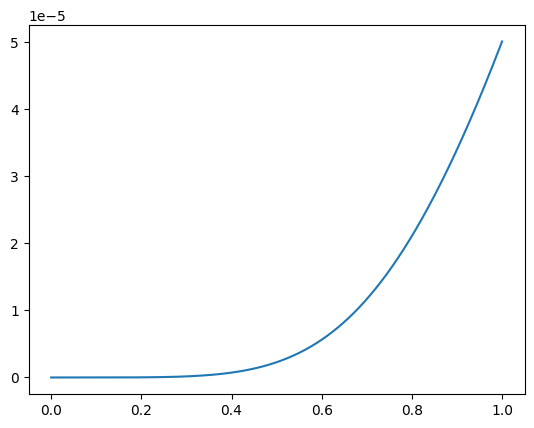

In [ ]:
plt.plot(r1, np.abs(psi1))

In [ ]:
_, psi0 = compute_psi0(0.5-0.2j)
ratio = np.max(np.abs(psi1)) / np.max(np.abs(psi0))
print(ratio)


3.530918405612207e-05


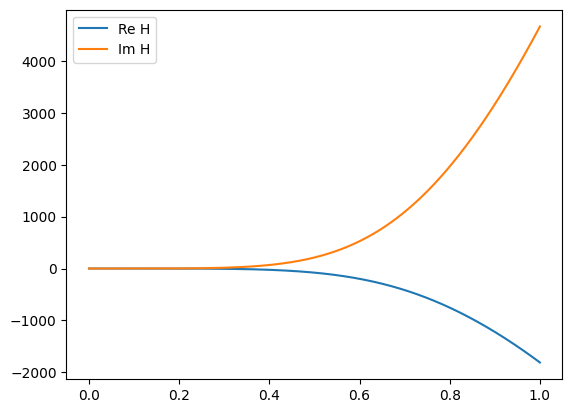

In [ ]:
plt.plot(r1, H.real, label="Re H")
plt.plot(r1, H.imag, label="Im H")
plt.legend()


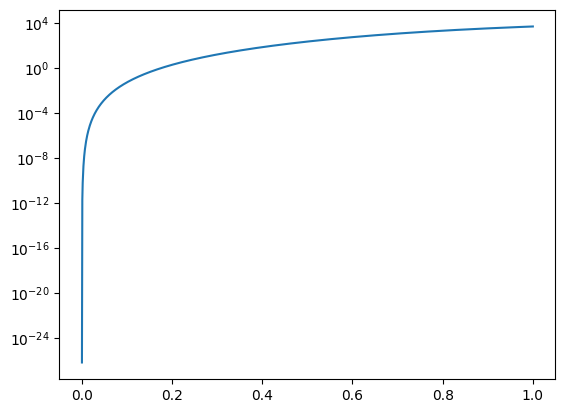

In [ ]:
plt.semilogy(r1, np.abs(H))


In [ ]:
# r, H are arrays you already have
import numpy as np

print("H real: min, max =", np.min(H.real), np.max(H.real))
print("H imag: min, max =", np.min(H.imag), np.max(H.imag))
print("max |H| =", np.max(np.abs(H)))

# physical psi1 for your Ken
Ken_val = 1e-8    # whatever Ken you will use
psi1_phys = Ken_val * H
print("max |psi1_phys| =", np.max(np.abs(psi1_phys)))
print("ratio max|psi1_phys| / max|psi0| =", np.max(np.abs(psi1_phys))/np.max(np.abs(psi0)))

# check denominators that commonly blow up
enuminus_vals = 4*np.exp(nu_spline(r1)) - r1**2 * ((0.5-0.2j)**2)  # replace omega_val
print("min |enuminus| =", np.min(np.abs(enuminus_vals)))
# more denominators:
denom_vals = 1.0 - 2.0*m_spline(r1)/r1
print("min |denom| =", np.min(np.abs(denom_vals)))


NameError: name 'H' is not defined

In [ ]:
Ken=0
print(etaf(eps),eta_p(eps),eta_2p(eps))

0j 0j (-0+0j)


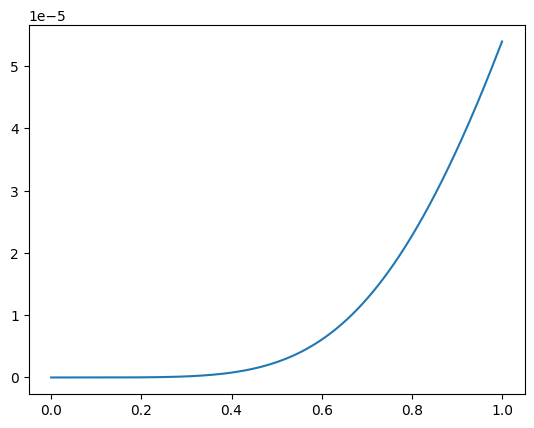

In [ ]:
plt.plot(r1, psi1.imag)

# QNM viscous solution

In [ ]:
def interior_solution(om, K_visc, eps=1e-6):

  r1, psi1, H, psi0_spline = solve_firstorder_Psi1(om, K_visc, eps)
  psi1_spline = ComplexSpline(r1, psi1)
  #print(om, r1.shape, psi1.shape)
  return {
      'r':r1,
      'psi0spline': psi0_spline,
      'psi0p_spline': psi0_spline.derivative(),
      'psi1': psi1,
      'psi1spline': psi1_spline,
      'psi1p_spline': psi1_spline.derivative(),
      'H': H
  }

def wronskian(profile, omega, l, K_visc, r_m, r_max, r0=1e-6, order=4):

  R, M = profile['R'], profile['M']

  int_sol = interior_solution(omega, K_visc, eps=r0)
  inter_sol = integrate_outward_from_R(profile, int_sol, omega, l, r_m)
  ext_sol = integrate_from_infinity_series(omega, l, M, r_m, r_max, order=order)

  psi_in_rm, dpsi_in_rm = inter_sol(r_m)
  psi_out_rm, dpsi_out_rm = ext_sol(r_m)

  W = (psi_out_rm * dpsi_in_rm - psi_in_rm * dpsi_out_rm)
  return W


In [ ]:
res_int = interior_solution(0.2-0.2j, 1e-8)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


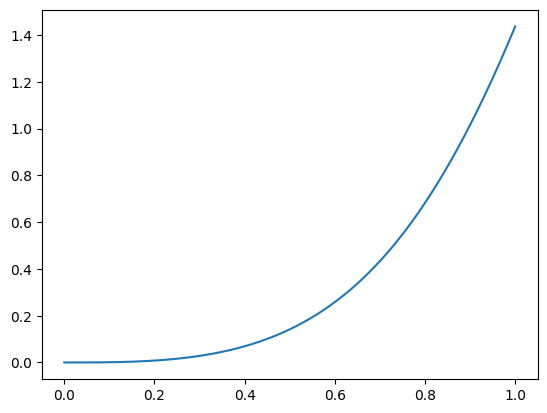

In [ ]:
plt.plot(res_int['r'], res_int['psi0spline'](res_int['r']))

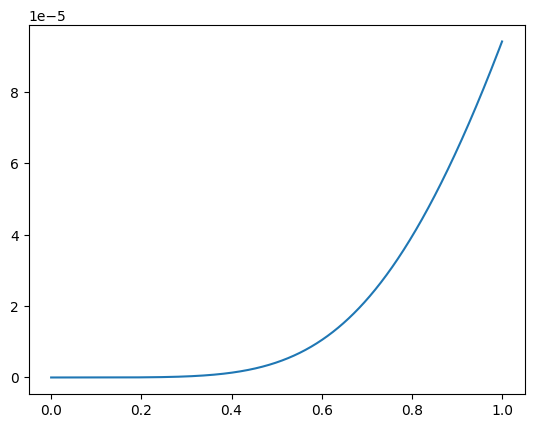

In [ ]:
plt.plot(res_int['r'], np.abs(res_int['psi1']))

In [ ]:
print(res['psi0spline'](1) + res['psi1spline'](1), res['psi0p_spline'](1)+res['psi1p_spline'](1))


(1.4127905503334717+5.3978772546619386e-05j) (4.523981800786975+0.00018924263955065384j)


In [ ]:
print(res['psi0spline'](1) + res['psi1spline'](1), res['psi0p_spline'](1)+res['psi1p_spline'](1))


(1.4127905504073082+5.397877544795949e-05j) (4.523981800874629+0.000189242632476739j)


In [ ]:
wronskian(profile, 0.5, 2, 1e-8, 1.01, 30, 1e-6, order=4)

0.5 (1200,) (1200,)


np.complex128(-100.08311242289979-38.30321875175354j)

In [ ]:
from tqdm import tqdm

def scan_param(profile, l, K_visc, re_range, im_range, r_m, r_max, r0=1e-6):
  Re = np.linspace(*re_range)
  Im = np.linspace(*im_range)

  heat = np.empty((len(Re), len(Im)))

  for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
    for j, im in enumerate(Im):
      om = re + 1j * im
      W = wronskian(profile, om, l, K_visc, r_m, r_max, r0=r0)
      heat[i, j] = np.log10(max(1e-30, abs(W)))

  return Re, Im, heat


Scanning Re(ω): 100%|██████████| 100/100 [7:06:04<00:00, 255.64s/it]


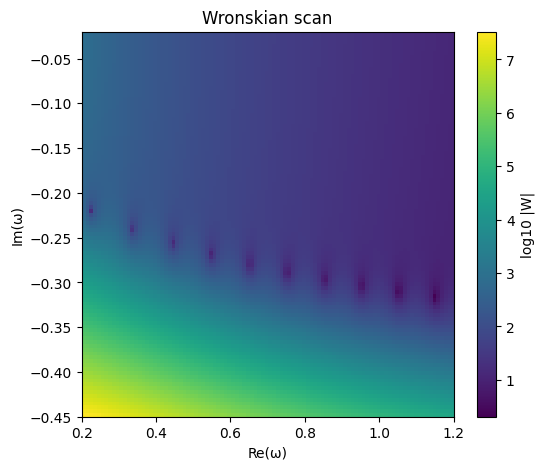

In [ ]:
K_visc = 1e-8
r_max = 30
Re, Im, heat = scan_param(profile, 2, K_visc, re_range=(0.2, 1.2, 100),im_range=(-0.45, -0.02, 100),r_m=1.01, r_max=r_max)

plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('Wronskian scan')
plt.show()


In [ ]:
from scipy.optimize import root
def find_qnm_wronskian(profile, l, omega_guess, r_m, r_max, K_visc, r0= 1e-6, tol=1e-14, maxfev=300, order=4):
  def F(xy):
    om = xy[0] + 1j * xy[1]
    W = wronskian(profile, om, l, K_visc, r_m, r_max, r0=r0,order=order)
    return np.array([W.real, W.imag])

  x0 = np.array([omega_guess.real, omega_guess.imag],float)
  sol = root(F,x0, method='lm', tol=tol)
  if not sol.success:
    raise RuntimeError(f"QNM wronskian scan failed: {sol.message}")
  om_star = sol.x[0] + 1j* sol.x[1]
  Wf = wronskian(profile, om_star, l, K_visc, r_m, r_max, r0=r0, order=order)

  info = {'success':bool(sol.success), 'message': sol.message, 'nfev': sol.nfev, 'qnm': om_star, 'W': Wf, 'abs(W)': np.abs(Wf)}
  print(f"success={info['success']} message={info['message']}")
  print(f"ω* = {om_star:.12g}  |W| = {abs(Wf):.3e}  at r_m={r_m}, r_max={r_max:.3g}")

  return om_star, info



In [ ]:
r_m

1.01

In [ ]:
omega_trial = 0.2 - 0.2j

for i in [1.01, 1.02, 1.03]:
  r_m = i
  find_qnm_wronskian(profile, 2, omega_trial, r_m=r_m, r_max=r_max, K_visc=1e-8)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610342-0.219014445687j  |W| = 4.850e-09  at r_m=1.01, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610342-0.219014445689j  |W| = 3.348e-08  at r_m=1.02, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.21988161034-0.219014445687j  |W| = 1.327e-08  at r_m=1.03, r_max=30


In [ ]:
omega_trial = 0.2 - 0.2j

for i in [1.01, 1.02, 1.03]:
  r_m = i
  find_qnm_wronskian(profile, 2, omega_trial, r_m=r_m, r_max=r_max, K_visc=1e-15)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619411-0.219014442849j  |W| = 3.915e-08  at r_m=1.01, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619409-0.219014442847j  |W| = 4.669e-08  at r_m=1.02, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619412-0.219014442849j  |W| = 2.102e-08  at r_m=1.03, r_max=30


In [ ]:
omega_trial = 0.2 - 0.2j

for i in [1.01, 1.02, 1.03]:
  r_m = i
  find_qnm_wronskian(profile, 2, omega_trial, r_m=r_m, r_max=r_max, K_visc=0)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619409-0.219014442846j  |W| = 3.671e-08  at r_m=1.01, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.21988161941-0.219014442846j  |W| = 3.591e-08  at r_m=1.02, r_max=30
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881619408-0.219014442844j  |W| = 7.425e-08  at r_m=1.03, r_max=30


In [ ]:
perfect = 0.219881619409-0.219014442846j


In [ ]:
perfect.imag - (-0.22)

0.0009855571540000052

In [ ]:
profile['M']

np.float64(0.20000000000004955)

In [ ]:
np.array(qnm_tol)*profile['M']

array([0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.04397632-0.04380289j, 0.04397632-0.04380289j,
       0.0

In [ ]:
perfect.imag - np.array(qnm).imag

array([5.74475578e-10, 4.98240699e-10, 4.33271807e-10, 3.76808251e-10,
       3.28019611e-10, 2.82465079e-10, 2.45701237e-10, 2.13682155e-10,
       1.88532356e-10, 1.61579611e-10, 1.42656692e-10, 1.22775012e-10,
       1.05641051e-10, 9.30953370e-11, 8.28422886e-11, 6.97417402e-11,
       6.20819784e-11, 5.17783871e-11, 4.62446192e-11, 4.04002942e-11,
       3.74563158e-11, 3.02735337e-11, 2.66375810e-11, 2.23811802e-11,
       2.20781726e-11, 1.79326831e-11, 1.63962455e-11, 1.27044208e-11,
       1.24149302e-11, 1.07850118e-11, 9.01051456e-12, 7.14761583e-12,
       8.41177128e-12, 7.10237424e-12, 4.89983054e-12, 5.24413846e-12,
       3.99288935e-12, 4.55530058e-12, 4.55016580e-12, 4.48185933e-12,
       1.79564696e-12, 2.64777089e-12, 2.95927172e-12, 2.87478374e-12,
       3.93859945e-12, 1.48608903e-12, 1.69203540e-12, 9.22734111e-13,
       2.14350759e-12, 2.34853803e-12])

In [ ]:
np.array(qnm).imag

array([-0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444,
       -0.21901444, -0.21901444, -0.21901444, -0.21901444, -0.21901444])

In [ ]:

qnm = []

Kvals = np.logspace(-6, -9, 50)

r_m = 1.01
r_max = 30

for i in Kvals:
  K_visc = i
  print(K_visc)
  qnm.append(find_qnm_wronskian(profile, 2, omega_trial, r_m, r_max, K_visc)[0])

qnm

1e-06
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610163-0.219014445983j  |W| = 6.717e-09  at r_m=1.01, r_max=30
8.685113737513521e-07
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610185-0.219014445945j  |W| = 1.146e-08  at r_m=1.01, r_max=30
7.543120063354623e-07
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.21988161021-0.219014445913j  |W| = 1.421e-08  at r_m=1.01, r_max=30
6.55128556859551e-07
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610227-0.219014445881j  |W| = 1.552e-08  at r_m=1.01, r_max=30
5.689866029018293e-07
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881610242-0.219014445855j  |W| = 2.407e-08  at r_m=1.01, r_max=30
4.941713361323838e-07
success=True message=The relative error b

[np.complex128(0.21988161016283703-0.21901444598330286j),
 np.complex128(0.21988161018456345-0.21901444594506875j),
 np.complex128(0.219881610210151-0.21901444591258568j),
 np.complex128(0.2198816102267227-0.2190144458813632j),
 np.complex128(0.21988161024249162-0.219014445854914j),
 np.complex128(0.2198816102528743-0.2190144458319178j),
 np.complex128(0.219881610269158-0.2190144458134873j),
 np.complex128(0.21988161027571063-0.2190144457969724j),
 np.complex128(0.21988161028540465-0.21901444578041707j),
 np.complex128(0.2198816102951649-0.21901444576885887j),
 np.complex128(0.21988161029893727-0.21901444575668333j),
 np.complex128(0.2198816103055637-0.21901444574883175j),
 np.complex128(0.2198816103108074-0.2190144457403492j),
 np.complex128(0.21988161031439096-0.21901444573276405j),
 np.complex128(0.2198816103175356-0.21901444572685289j),
 np.complex128(0.2198816103199094-0.21901444571783105j),
 np.complex128(0.2198816103232715-0.21901444571438422j),
 np.complex128(0.2198816103264377

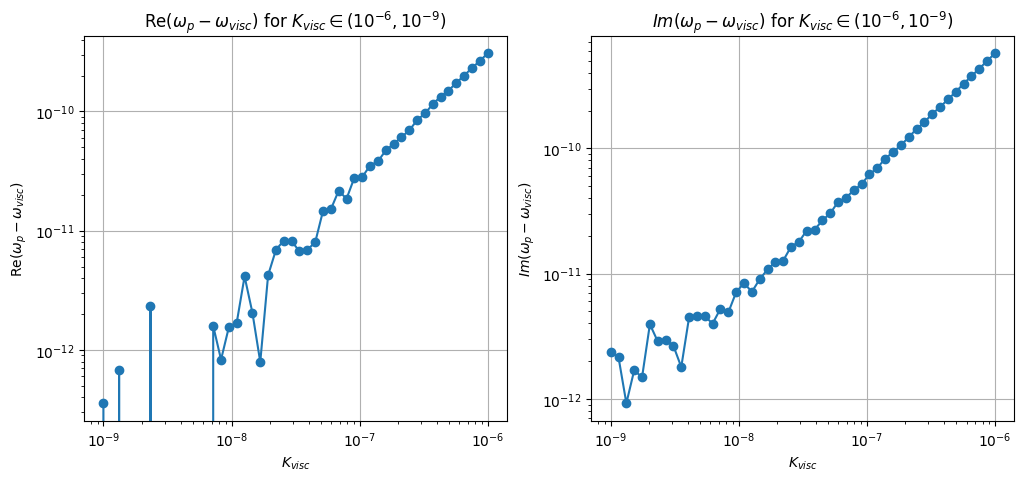

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title(r'Re($\omega_{p} - \omega_{visc}$) for $K_{visc}\in (10^{-6}, 10^{-9})$')
plt.plot(Kvals, perfect.real-np.array(qnm).real, marker='o')
#plt.scatter(0, perfect.real, label='Perfect fluid', marker='*', color='r')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'Re($\omega_{p} - \omega_{visc}$)')
plt.xlabel(r'$K_{visc}$')
plt.grid(True)

plt.subplot(1,2,2)
plt.title(r'$Im(\omega_{p} - \omega_{visc}$) for $K_{visc}\in (10^{-6}, 10^{-9})$')
plt.plot(Kvals, (perfect.imag-np.array(qnm).imag), marker='o')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$Im(\omega_{p} - \omega_{visc}$)')
plt.xlabel(r'$K_{visc}$')
plt.grid(True)

plt.show()
plt.tight_layout()

#plt.savefig('Difference_Plot.pdf')

In [ ]:
import pickle

with open("qnms_Visc_1em10.pkl", "wb") as f:
    pickle.dump(qnm, f)

print("✅ QNMs saved to qnms_Visc_1em10.pkl")

✅ QNMs saved to qnms_Visc_1em10.pkl


In [ ]:

qnm_tol = []

Kvals = np.logspace(-5, -8, 50)

r_m = 1.01
r_max = 30

for i in Kvals:
  K_visc = i
  print(K_visc)
  qnm_tol.append(find_qnm_wronskian(profile, 2, omega_trial, r_m, r_max, K_visc)[0])

qnm_tol

1e-05
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881615935-0.219014448653j  |W| = 1.341e-08  at r_m=1.01, r_max=30
8.68511373751352e-06
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881616442-0.219014447879j  |W| = 1.960e-08  at r_m=1.01, r_max=30
7.5431200633546225e-06
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881616868-0.21901444721j  |W| = 4.479e-08  at r_m=1.01, r_max=30
6.5512855685955095e-06
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881617228-0.219014446629j  |W| = 4.562e-08  at r_m=1.01, r_max=30
5.689866029018293e-06
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.219881617536-0.219014446129j  |W| = 6.825e-08  at r_m=1.01, r_max=30
4.941713361323839e-06
success=True message=The relative error

[np.complex128(0.21988161593458103-0.21901444865322123j),
 np.complex128(0.21988161644154397-0.21901444787919533j),
 np.complex128(0.21988161686792576-0.2190144472096204j),
 np.complex128(0.2198816172284812-0.21901444662850506j),
 np.complex128(0.2198816175361505-0.21901444612915794j),
 np.complex128(0.2198816177991608-0.2190144456933794j),
 np.complex128(0.21988161802486542-0.21901444531584785j),
 np.complex128(0.219881618213262-0.2190144449887627j),
 np.complex128(0.21988161837785378-0.2190144447088995j),
 np.complex128(0.21988161851341492-0.21901444445899582j),
 np.complex128(0.21988161864003825-0.21901444424731117j),
 np.complex128(0.219881618745651-0.21901444406408935j),
 np.complex128(0.219881618835466-0.21901444390031552j),
 np.complex128(0.2198816189092742-0.21901444376387844j),
 np.complex128(0.21988161897833414-0.21901444364256828j),
 np.complex128(0.21988161903551182-0.21901444353707955j),
 np.complex128(0.21988161908337167-0.21901444344490034j),
 np.complex128(0.21988161912

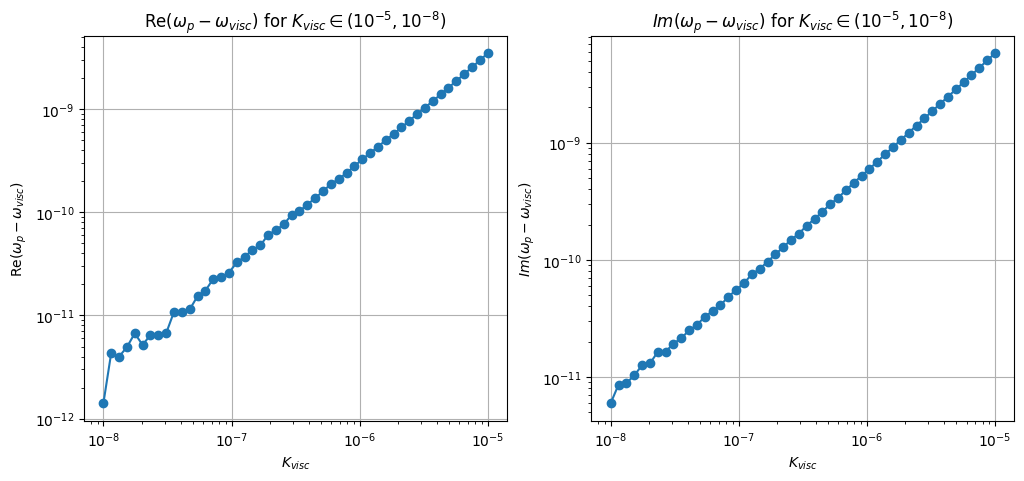

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title(r'Re($\omega_{p} - \omega_{visc}$) for $K_{visc}\in (10^{-5}, 10^{-8})$')
plt.plot(Kvals, perfect.real-np.array(qnm_tol).real, marker='o')
#plt.scatter(0, perfect.real, label='Perfect fluid', marker='*', color='r')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'Re($\omega_{p} - \omega_{visc}$)')
plt.xlabel(r'$K_{visc}$')
plt.grid(True)

plt.subplot(1,2,2)
plt.title(r'$Im(\omega_{p} - \omega_{visc}$) for $K_{visc}\in (10^{-5}, 10^{-8})$')
plt.plot(Kvals, (perfect.imag-np.array(qnm_tol).imag), marker='o')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$Im(\omega_{p} - \omega_{visc}$)')
plt.xlabel(r'$K_{visc}$')
plt.grid(True)

plt.show()
plt.tight_layout()

#plt.savefig('Difference_Plot.pdf')

In [ ]:
perfect

(0.219881619409-0.219014442846j)

In [ ]:
import pickle

with open("qnms_Visc_1em14.pkl", "wb") as f:
    pickle.dump(qnm_tol, f)

print("✅ QNMs saved to qnms_Visc_1em14.pkl")

✅ QNMs saved to qnms_Visc_1em14.pkl


In [ ]:
qnm_tol

[np.complex128(0.21988161593458103-0.21901444865322123j),
 np.complex128(0.21988161644154397-0.21901444787919533j),
 np.complex128(0.21988161686792576-0.2190144472096204j),
 np.complex128(0.2198816172284812-0.21901444662850506j),
 np.complex128(0.2198816175361505-0.21901444612915794j),
 np.complex128(0.2198816177991608-0.2190144456933794j),
 np.complex128(0.21988161802486542-0.21901444531584785j),
 np.complex128(0.219881618213262-0.2190144449887627j),
 np.complex128(0.21988161837785378-0.2190144447088995j),
 np.complex128(0.21988161851341492-0.21901444445899582j),
 np.complex128(0.21988161864003825-0.21901444424731117j),
 np.complex128(0.219881618745651-0.21901444406408935j),
 np.complex128(0.219881618835466-0.21901444390031552j),
 np.complex128(0.2198816189092742-0.21901444376387844j),
 np.complex128(0.21988161897833414-0.21901444364256828j),
 np.complex128(0.21988161903551182-0.21901444353707955j),
 np.complex128(0.21988161908337167-0.21901444344490034j),
 np.complex128(0.21988161912

# CF rebuilt

In [ ]:
import numpy as np

# ---------- Appendix B coefficient builders ----------

def cde_coeffs(M, R2, l, omega):
    """
    Return the coefficients c0..c3, d0..d2, e0,e1 from Eq. (B4).
    """
    M = float(M)
    R2 = float(R2)
    w = -omega

    c0 = 1.0 - 2.0*M/R2
    c1 = 6.0*M/R2 - 2.0
    c2 = 1.0 - 6.0*M/R2
    c3 = 2.0*M/R2

    d0 = -2j*w*R2 + 6.0*M/R2 - 2.0
    d1 = 2.0*(1.0 - 6.0*M/R2)
    d2 = 6.0*M/R2

    e0 = 6.0*M/R2 - l*(l+1.0)
    e1 = -6.0*M/R2

    return (c0, c1, c2, c3, d0, d1, d2, e0, e1)


def four_term_recurrence(M, R2, l, omega, Nmax):
    """
    Build alpha_n, beta_n, gamma_n, delta_n for n=0..Nmax (Appendix B, Eq. (B7)).
    We will only use n>=1 for alpha,beta,gamma, and n>=2 for delta.
    """
    c0, c1, c2, c3, d0, d1, d2, e0, e1 = cde_coeffs(M, R2, l, omega)

    # allocate as complex arrays
    alpha = np.zeros(Nmax+1, dtype=complex)
    beta  = np.zeros(Nmax+1, dtype=complex)
    gamma = np.zeros(Nmax+1, dtype=complex)
    delta = np.zeros(Nmax+1, dtype=complex)

    # n >= 1
    for n in range(1, Nmax+1):
        alpha[n] = n*(n+1)*c0
        beta[n]  = (n-1)*n*c1 + n*d0
        gamma[n] = (n-2)*(n-1)*c2 + (n-1)*d1 + e0
        if n >= 2:
            delta[n] = (n-3)*(n-2)*c3 + (n-2)*d2 + e1

    return alpha, beta, gamma, delta

def three_term_from_four(alpha, beta, gamma, delta, a1_over_a0, Nmax):
    """
    Perform Gaussian elimination (Appendix B, Eqs. B10–B12) to reduce
    the 4-term recurrence to a 3-term one.

    Inputs:
        alpha,beta,gamma,delta : arrays from four_term_recurrence
        a1_over_a0             : complex, ratio a1/a0 from matching
        Nmax                   : highest n index to keep in the recurrence
    Returns:
        alpha_hat, beta_hat, gamma_hat (length Nmax+1).
    """
    alpha_hat = np.zeros(Nmax+1, dtype=complex)
    beta_hat  = np.zeros(Nmax+1, dtype=complex)
    gamma_hat = np.zeros(Nmax+1, dtype=complex)

    # Eq. (B10): n = 0 "initial" coefficients
    beta_hat[0]  = a1_over_a0
    alpha_hat[0] = -1.0 + 0j   # α̂_0

    # n = 1
    alpha_hat[1] = alpha[1]
    beta_hat[1]  = beta[1]
    gamma_hat[1] = gamma[1]

    # n >= 2: Gaussian elimination, Eq. (B12)
    for n in range(2, Nmax+1):
        alpha_hat[n] = alpha[n]
        beta_hat[n]  = beta[n]  - alpha_hat[n-1]*delta[n]/gamma_hat[n-1]
        gamma_hat[n] = gamma[n] - beta_hat[n-1]*delta[n]/gamma_hat[n-1]

    return alpha_hat, beta_hat, gamma_hat

def psi_and_derivative_at_R2(profile, omega, K_visc, R2, eps=1e-6):
    """
    Use your existing interior machinery to get Psi(R2) and Psi'(R2)
    on the *exterior* RW variable.
    """
    int_sol = interior_solution(omega, K_visc, eps=eps)
    # total axial RW field: psi0 + psi1 (if present)
    psi0 = int_sol['psi0spline'](R2)
    psi0p = int_sol['psi0p_spline'](R2)

    psi1 = int_sol['psi1spline'](R2)
    psi1p = int_sol['psi1p_spline'](R2)

    Psi_R2  = psi0 + psi1
    dPsi_R2 = psi0p + psi1p
    return Psi_R2, dPsi_R2

def a1_over_a0_from_interior(profile, omega, K_visc, R2, eps=1e-6):
    M = profile['M']
    Psi_R2, dPsi_R2 = psi_and_derivative_at_R2(profile, omega, K_visc, R2, eps=eps)

    # guard against Psi_R2 = 0 (shouldn't happen if matching is correct)
    if Psi_R2 == 0:
        raise RuntimeError("Psi(R2) = 0, cannot compute a1/a0.")

    num = dPsi_R2 + 1j*omega*R2/(R2 - 2.0*M) * Psi_R2
    a1_over_a0 = (R2 / Psi_R2) * num
    return a1_over_a0

def continued_fraction_f0(alpha_hat, beta_hat, gamma_hat, Nmax):
    """
    Compute f0(ω) = β̂0 - α̂0 * CF, where CF is the continued fraction in Eq. (B18),
    truncated at Nmax using downward recursion.
    """
    # Downward recursion for tail: F_n = γ̂_n / (β̂_n - α̂_n F_{n+1})
    F = 0.0 + 0.0j
    for n in range(Nmax, 1, -1):
        denom = beta_hat[n] - alpha_hat[n]*F
        if denom == 0:
            denom = 1e-30  # numerical guard
        F = gamma_hat[n] / denom

    # Continued fraction evaluated at n=1
    CF_denom = beta_hat[1] - alpha_hat[1]*F
    if CF_denom == 0:
        CF_denom = 1e-30

    CF = gamma_hat[1] / CF_denom

    # Final f0(ω)
    f0 = beta_hat[0] - alpha_hat[0]*CF
    return f0

def leaver_cf_residual(profile, l, omega, K_visc, R2, Nmax=200, eps=1e-6):
    """
    Compute the continued-fraction residual f0(ω) for the RW equation,
    using the interior solution to fix a1/a0 at r = R2.

    Parameters:
        profile : dict with 'M', 'R', ...
        l       : multipole index
        omega   : complex frequency
        K_visc  : viscosity parameter (0 for perfect fluid)
        R2      : matching radius outside the star (R < R2, R2 > 2M)
        Nmax    : truncation order of continued fraction
        eps     : inner integration radius for interior solution

    Returns:
        complex f0(ω); QNMs satisfy f0(ω) = 0.
    """
    M = profile['M']
    # 1. Get a1/a0 from interior
    a1a0 = a1_over_a0_from_interior(profile, omega, K_visc, R2, eps=eps)

    # 2. Build 4-term recurrence
    alpha, beta, gamma, delta = four_term_recurrence(M, R2, l, omega, Nmax)

    # 3. Reduce to 3-term recurrence
    alpha_hat, beta_hat, gamma_hat = three_term_from_four(alpha, beta, gamma, delta,
                                                          a1a0, Nmax)

    # 4. Evaluate continued fraction residual f0
    f0 = continued_fraction_f0(alpha_hat, beta_hat, gamma_hat, Nmax)
    return f0


In [ ]:
from scipy.optimize import root

def find_qnm_cf(profile, l, omega_guess, R2, K_visc=0.0,
                Nmax=200, eps=1e-6, tol=1e-10, maxfev=200):
    """
    Find a QNM using Leaver's continued fraction method, with interior
    matching at r=R2.

    omega_guess : complex initial guess (e.g. your Wronskian result)
    """

    def F(xy):
        w = xy[0] + 1j*xy[1]
        f0 = leaver_cf_residual(profile, l, w, K_visc, R2, Nmax=Nmax, eps=eps)
        # We want f0(w) = 0; return real/imag parts
        return np.array([f0.real, f0.imag])

    x0 = np.array([omega_guess.real, omega_guess.imag], dtype=float)
    sol = root(F, x0, method='lm', tol=tol, options={'maxiter': maxfev})

    if not sol.success:
        raise RuntimeError(f"CF QNM search failed: {sol.message}")

    w_star = sol.x[0] + 1j*sol.x[1]
    return w_star, sol


In [ ]:
2*M

np.float64(0.4000000000000991)

In [ ]:
M = profile['M']
R = profile['R']
R2 = 3*R  # choose any R2 > R, > 2M, not too large

omega_wronskian = 0.200402181563 - 0.15249138899j  # your previous result
omega_cf, sol_cf = find_qnm_cf(profile, l=2, omega_guess=omega_wronskian,
                               R2=R2, K_visc=1e-8, Nmax=200)

print("Wronskian ω* =", omega_wronskian)
print("CF        ω* =", omega_cf)
print("|Δω| =", abs(omega_cf - omega_wronskian))


Wronskian ω* = (0.200402181563-0.15249138899j)
CF        ω* = (0.10575032218856839+0.3950687940407953j)
|Δω| = 0.5556807793362618


In [ ]:
sol_cf

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 4.815e+00 -8.476e-03]
       x: [ 1.540e-01  2.052e-02]
   cov_x: [[ 7.596e+02 -1.695e+02]
           [-1.695e+02  3.782e+01]]
  method: lm
    nfev: 38
    fjac: [[-1.267e+03  1.875e-02]
           [-2.827e+02 -3.628e-02]]
    ipvt: [1 0]
     qtf: [-4.815e+00  1.021e-02]

In [ ]:
interior_solution(0.2-0.2j, 0)

{'r': array([1.00000000e-06, 1.50000000e-06, 3.35028936e-06, ...,
        9.98314467e-01, 9.99314466e-01, 1.00000000e+00]),
 'psi0spline': <__main__.ComplexSpline at 0x7834e91878f0>,
 'psi0p_spline': <function __main__.ComplexSpline.derivative.<locals>.<lambda>(x)>,
 'psi1': array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]),
 'psi1spline': <__main__.ComplexSpline at 0x7834e8c86b10>,
 'psi1p_spline': <function __main__.ComplexSpline.derivative.<locals>.<lambda>(x)>,
 'H': None}

# CF BH - Leaver

In [ ]:

# Constants for gravitational perturbations
s = -2
l = 2
A_s = (l - s) * (l + s + 1)  # = 4 for s=-2,l=2
r_plus = 2.0  # M = 1/2

def recurrence_coeffs(n, omega):

    C0 = -s + 1 - 2j * omega * r_plus
    C1 = -4 + 8j * omega * r_plus
    C2 = s + 3 - 4j * omega * r_plus
    C3 = -s - 1 + 4j * omega * r_plus + 8 * omega**2 * r_plus**2 - A_s
    C4 = s + 1 - 2*(s+2)*1j*omega*r_plus - 4*omega**2*r_plus**2

    alpha = n**2 + (C0+1)*n + C0
    beta  = -2*n**2 + (C1+2)*n + C3
    gamma = n**2 + (C2-3)*n + C4 - C2 + 2

    return alpha, beta, gamma

def continued_fraction(omega, Nmax=200):
    # Backward recurrence for continued fraction
    cf = 0.0 + 0.0j
    for n in reversed(range(1, Nmax)):
        alpha, beta, gamma = recurrence_coeffs(n, omega)
        cf = gamma / (beta - alpha * cf)
    # Return full CF expression for n=0
    alpha0, beta0, gamma0 = recurrence_coeffs(0, omega)
    return beta0 - alpha0 * cf

from scipy.optimize import root

def find_qnm_leaver(omega_guess, Nmax=200):
    def F(z):
        omega = z[0] + 1j*z[1]
        cf = continued_fraction(omega, Nmax)
        return [cf.real, cf.imag]

    z0 = [omega_guess.real, omega_guess.imag]
    sol = root(F, z0)

    if not sol.success:
        raise RuntimeError("Root search failed: " + sol.message)

    return sol.x[0] + 1j*sol.x[1]


In [ ]:
omega_guess = 0.36 - 0.1j
omega_leaver = find_qnm_leaver(omega_guess)

print("Leaver ωM =", omega_leaver)
print("Leaver ω =", omega_leaver*2)


Leaver ωM = (0.373671684421819-0.08896231568839807j)
Leaver ω = (0.747343368843638-0.17792463137679615j)


# Hybrid method

In [ ]:
omega_leaver*2

np.complex128(0.747343368843638-0.17792463137679615j)

In [ ]:
def exterior_coeffs_star(omega, l, M, R2, psi_R2, dpsi_R2, Nmax=200):
    # coefficients c0..e1
    c0 = 1 - 2*M/R2
    c1 = 6*M/R2 - 2
    c2 = 1 - 6*M/R2
    c3 = 2*M/R2

    d0 = -2j*omega*R2 + 6*M/R2 - 2
    d1 = 2*(1 - 6*M/R2)
    d2 = 6*M/R2

    e0 = 6*M/R2 - l*(l+1)
    e1 = -6*M/R2

    # chi(R2)
    chi_R2 = (R2 - 2*M)**(-1j*2*M*omega) * np.exp(-1j*omega*R2)

    # a0, a1 from (B8)-(B9)
    a0 = psi_R2 / chi_R2
    a1_over_a0 = (R2/psi_R2) * (dpsi_R2 + 1j*omega*R2/(R2 - 2*M)*psi_R2)
    a1 = a1_over_a0 * a0

    # allocate a_n
    a = np.zeros(Nmax+1, dtype=complex)
    a[0] = a0
    a[1] = a1

    # helper functions for recurrence coefficients
    def alpha(n): return n*(n+1)*c0
    def beta(n):  return (n-1)*n*c1 + n*d0
    def gamma(n): return (n-2)*(n-1)*c2 + (n-1)*d1 + e0
    def delta(n): return (n-3)*(n-2)*c3 + (n-2)*d2 + e1

    # n=1 special case: α1 a2 + β1 a1 + γ1 a0 = 0
    a[2] = -(beta(1)*a[1] + gamma(1)*a[0]) / alpha(1)

    # general 4-term recurrence for n >= 2
    for n in range(2, Nmax):
        a[n+1] = -(beta(n)*a[n] + gamma(n)*a[n-1] + delta(n)*a[n-2]) / alpha(n)

    return a
def exterior_series_solution(a, omega, l, M, R2):
    # returns a callable giving (Psi_ext, dPsi_ext) at r

    def chi(r):
        return (r - 2*M)**(-1j*2*M*omega) * np.exp(-1j*omega*r)

    def dchi_dr(r):
        # derivative of chi(r)
        term1 = (-1j*2*M) * (r - 2*M)**(-1j*2*M*omega - 1) * np.exp(-1j*omega*r)
        term2 = (-1j*omega) * (r - 2*M)**(-1j*2*M*omega) * np.exp(-1j*omega*r)
        return term1 + term2

    def z_of_r(r):
        return 1.0 - R2/r

    def dz_dr(r):
        return R2 / r**2

    def phi_and_dphi(r):
        z = z_of_r(r)
        # Horner-like evaluation
        n = np.arange(len(a), dtype=int)
        # phi(z)
        z_powers = z**n
        phi = np.sum(a * z_powers)
        # phi'(z) = sum n a_n z^{n-1}
        if z == 0:
            dphi_dz = a[1]  # limit z->0
        else:
            dphi_dz = np.sum(n[1:] * a[1:] * z**(n[1:]-1))
        return phi, dphi_dz

    def Psi_ext(r):
        phi, _ = phi_and_dphi(r)
        return chi(r) * phi

    def dPsi_ext(r):
        phi, dphi_dz = phi_and_dphi(r)
        ch = chi(r)
        dch = dchi_dr(r)
        dz = dz_dr(r)
        return dch*phi + ch*dphi_dz*dz

    return Psi_ext, dPsi_ext


In [ ]:
def interior_solution(om, K_visc, eps=1e-6):

  r1, psi1, H, psi0_spline = solve_firstorder_Psi1(om, K_visc, eps)
  psi1_spline = ComplexSpline(r1, psi1)
  #print(om, r1.shape, psi1.shape)
  return {
      'r':r1,
      'psi0spline': psi0_spline,
      'psi0p_spline': psi0_spline.derivative(),
      'psi1': psi1,
      'psi1spline': psi1_spline,
      'psi1p_spline': psi1_spline.derivative(),
      'H': H
  }

def wronskian(profile, omega, l, K_visc, r_m, r_max, r0=1e-6, order=4):

  R, M = profile['R'], profile['M']

  int_sol = interior_solution(omega, K_visc, eps=r0)
  inter_sol = integrate_outward_from_R(profile, int_sol, omega, l, r_m)
  ext_sol = integrate_from_infinity_series(omega, l, M, r_m, r_max, order=order)

  psi_in_rm, dpsi_in_rm = inter_sol(r_m)
  psi_out_rm, dpsi_out_rm = ext_sol(r_m)

  W = (psi_out_rm * dpsi_in_rm - psi_in_rm * dpsi_out_rm)
  return W

def interior_boundary_values(int_sol, r):
    psi0s = int_sol['psi0spline']
    psi1s = int_sol['psi1spline']
    psi1ps = int_sol['psi1p_spline']

    Psi  = psi0s(r) + psi1s(r)
    dPsi = psi0s.derivative()(r) + psi1ps(r)
    return Psi, dPsi

def make_leaver_exterior_solution(profile, omega, int_sol, R2, l=2, Nmax=200):

    M = profile['M']

    # Interior values at matching point R2
    psi_R2, dpsi_R2 = interior_boundary_values(int_sol, R2)

    a = exterior_coeffs_star(omega, l, M, R2, psi_R2, dpsi_R2, Nmax)
    Psi_ext, dPsi_ext = exterior_series_solution(a, omega, l, M, R2)

    # return a function like your old ext_sol(r) -> (psi, dpsi)
    def ext_sol(r):
        return Psi_ext(r), dPsi_ext(r)

    return ext_sol


In [ ]:
def wronskian(profile, omega, l, K_visc, r_m, r_max=None, R2, r0=1e-6, R2=None, Nmax=200):

    R  = profile['R']
    M  = profile['M']

    # Where to match interior<->Leaver exterior
    if R2 is None:
        R2 = 1.2*R  # safe default just outside star

    # interior viscous solution
    int_sol = interior_solution(omega, K_visc, eps=r0)

    # interior upto rm
    psi_in_rm, dpsi_in_rm = interior_boundary_values(int_sol, r_m)

    # NEW: exterior from Leaver series
    ext_sol = make_leaver_exterior_solution(profile, omega, int_sol, R2=R2, l=l, Nmax=Nmax)
    psi_out_rm, dpsi_out_rm = ext_sol(r_m)

    # Wronskian
    W = psi_out_rm * dpsi_in_rm - psi_in_rm * dpsi_out_rm
    return W


In [ ]:
from scipy.optimize import root
def find_qnm_wronskian(profile, l, omega_guess, r_m, r_max, R2, K_visc, r0= 1e-6, tol=1e-14, maxfev=300, order=4):
  def F(xy):
    om = xy[0] + 1j * xy[1]
    W = wronskian(profile, om, l, K_visc, r_m, r_max, r0=r0)
    return np.array([W.real, W.imag])

  x0 = np.array([omega_guess.real, omega_guess.imag],float)
  sol = root(F,x0, method='lm', tol=tol)
  if not sol.success:
    raise RuntimeError(f"QNM wronskian scan failed: {sol.message}")
  om_star = sol.x[0] + 1j* sol.x[1]
  Wf = wronskian(profile, om_star, l, K_visc, r_m, r_max, r0=r0)

  info = {'success':bool(sol.success), 'message': sol.message, 'nfev': sol.nfev, 'qnm': om_star, 'W': Wf, 'abs(W)': np.abs(Wf)}
  print(f"success={info['success']} message={info['message']}")
  print(f"ω* = {om_star:.12g}  |W| = {abs(Wf):.3e}  at r_m={r_m}")

  return om_star, info



In [ ]:
rm = 1.3*profile['R']
R2 = rm

In [ ]:
omqnm = find_qnm_wronskian(profile, 2, 0.2-0.2j, rm, None, rm, 0)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 0.976914128602-0.211493080714j  |W| = 9.412e-01  at r_m=1.3


# Even perturbations

In [6]:
def lambda_of_r(r, m):
    m_vals = m(r) if callable(m) else m
    return -np.log(1.0 - 2.0 * m_vals / r)

profile= profiles[0.2]
T = 1e5 #Temperature
Ke = 4e25 / (T/1e5)**2 #cgs g cm^-1 s^-1
G = 6.67e-8
c = 3e10
conv = G/c**3
R_n = 1e6 # 10 km

def make_bg_splines(profile):
    r = profile['r']
    m = profile['m']
    p = profile['p']
    rho = profile['rho']
    nu = CubicSpline(r,profile['nu_vals_norm'])
    lam = CubicSpline(r, lambda_of_r(r,m))
    pprime = (CubicSpline(r,p)).derivative()
    rhoprime = (CubicSpline(r,rho)).derivative()
    cs2 = CubicSpline(r, (pprime(r)/rhoprime(r)))

    return {
        'r': r,
        'm': CubicSpline(r,m),
        'p': CubicSpline(r,p),
        'p_prime': pprime ,
        'rho': CubicSpline(r,rho),
        'rho_prime': rhoprime,
        'nu': nu,
        'lam': lam,
        'lam_p': lam.derivative(),
        'nu_p': nu.derivative(),
        's': 0,
        'sp': 0,
        'cs2': cs2
    }



Ken = 1e-7*(1/10)#Ke*conv * R_n; #cgs -> geometric cm^-1  # Arbitrary here we can set this to any value elsewhere
eps = 1e-6
rho_sat =  2.8e14 #cgs
bg = make_bg_splines(profile)
r_vals, m_spline, p_spline, rho_spline, nu_spline = bg['r'], bg['m'], bg['p'], bg['rho'], bg['nu']

r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4
rho_vals      = rho_spline(r_vals)
rho_cgs_vals  = rho_vals * 1.4e16
rho_cgs_spline = ComplexSpline(r_vals, rho_cgs_vals, k=3)

# Derivatives
rho_prime_spline  = rho_spline.derivative()
rho_2prime_spline = rho_spline.derivative(2)

rho_cgs_prime_spline  = rho_cgs_spline.derivative()
rho_cgs_2prime_spline = rho_cgs_spline.derivative(2)

nu_prime_spline = nu_spline.derivative()
p_prime_spline  = p_spline.derivative()

nu0 = nu_spline(eps)
p0 = p_spline(eps)
rho0 = rho_spline(eps)
lambd2 = 8*np.pi*rho0/3
elambd0 = lambda_of_r(eps,m_spline)

def p2o(r):
    return -0.5*(p0+rho0) *4*np.pi*(p0 + (rho0/3))
def rho2o(r):
    return p2o(r)/(p_prime_spline(eps)/rho_prime_spline(eps))
def nu2o(r):
    return (4*np.pi/3)*(rho0+3*p0)


In [13]:
class SourceTensor:
  def S01(self, r, omega): return 0.0
  def S01p(self, r, omega): return 0.0
  def S00(self, r, omega): return 0.0
  def S0A(self, r, omega): return 0.0
  def SZ(self, r, omega): return 0.0
  def S0(self, r, omega): return 0.0
  def S0p(self, r, omega): return 0.0
  def S1(self, r, omega): return 0.0
  def S1p(self, r, omega): return 0.0
  def SOm(self, r, omega): return 0.0

In [14]:
def init_conds_even_perfect(r, om, s=True):
  pi = cm.pi
  Whinit = 1*r**3
  if s==True:
    Kinit = +(rho0+p0)*r**2
  else:
    Kinit = -(rho0+p0)*r**2
  Xinit = (1/6)*cm.exp(-nu0/2)*(p0+rho0)*(-3*om**2 *Whinit + cm.exp(nu0)*(3*Kinit + 8*pi*Whinit*(3*p0+rho0))) *r**2     #((cm.exp(3*nu0/2)*pi*(3*p0**2 + 4*p0*rho0 + rho0**2))/(om**2 + 2*cm.exp(nu0)*pi*(3*p0 + rho0)))*eps**2
  H1init = (2/3)*(Kinit + 4*pi*Whinit)*(p0+rho0) *r**3                                                                  #((32*cm.exp(nu0)*pi**2 *Whinit*(p0+rho0)*(3*p0+rho0))/(9*om**2))*eps**3

  return np.array([Xinit.real, Xinit.imag, Whinit.real, Whinit.imag, H1init.real, H1init.imag, Kinit.real, Kinit.imag])


print(init_conds_even_perfect(eps, 0.5))


#Old init conds: [3.85586324e-14 0.00000000e+00 2.13262475e-19 0.00000000e+00 5.17056176e-37 0.00000000e+00 1.00000000e-12 0.00000000e+00]


[1.22629449e-26 0.00000000e+00 1.00000000e-18 0.00000000e+00
 3.03223754e-32 0.00000000e+00 2.13262475e-13 0.00000000e+00]


In [17]:
def evenSystem(r, y, om, bg,source: SourceTensor, l=2):
  Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
  pi = cm.pi

  Xh = Xhre + 1j*Xhim
  Wh = Whre + 1j*Whim
  H1 = H1re + 1j*H1im
  K = Kre + 1j*Kim

  S01 = source.S01(r, om)
  S00 = source.S00(r, om)
  S0A = source.S0A(r, om)
  SZ  = source.SZ(r,  om)
  S0  = source.S0(r,  om)
  S1  = source.S1(r,  om)
  SOm = source.SOm(r, om)
  S01p = source.S01p(r,om)
  S0p = source.S0p(r, om)
  S1p = source.S1p(r,om)
  drhods = 0

  m, p, rho, nu, lam, lam_p, nu_p, p_prime, rho_prime, s, sp, cs2 = bg['m'](r), bg['p'](r), bg['rho'](r), bg['nu'](r), bg['lam'](r), bg['lam_p'](r), bg['nu_p'](r), bg['p_prime'](r), bg['rho_prime'](r), bg['s'], bg['sp'], bg['cs2'](r)


  #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
  Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))

  Eh = (Xh/cs2) + drhods*Sigh


  Hdenom = 3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
  H = (-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

  Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
  Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
  Vh = Vhnum2/(2*om**2 *(rho+p))

  dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
  dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
  dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
  dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm


  return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])



In [9]:
bg['lam'](eps)

array(-2.86310319e-13)

In [10]:
bg['nu'](1)

array(-0.51082561)

In [24]:
evenSystem(eps, init_conds_even_perfect(eps, 0.5), 0.5, bg, source=SourceTensor())

array([ 6.39751205e-08,  0.00000000e+00,  7.44189145e-07,  0.00000000e+00,
        1.75611615e-06,  0.00000000e+00, -4.26530309e-07,  0.00000000e+00])

In [41]:
evenSystem(eps, init_conds_even_perfect(eps, 0.5), 0.5, bg, source=SourceTensor())

array([ 6.39751213e-08,  0.00000000e+00,  7.44189145e-07,  0.00000000e+00,
        1.75611615e-06,  0.00000000e+00, -4.26530309e-07,  0.00000000e+00])

In [9]:
r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4
def EvenSolver(omega, eps=1e-6):
  om = omega
  y0 = init_conds_even_perfect(eps, om)
  def rhs(r, y):
    return evenSystem(r, y, om, bg, source=SourceTensor())

  sol = solve_ivp(
      rhs, [eps, r_end], y0,
      method='Radau',
      rtol=1e-7, atol=1e-10,
      dense_output=False,vectorized=True,
      max_step=1e-3)


  if not sol.success:
      raise RuntimeError(f"integrator failed: {sol.message}")

  return sol

In [13]:
EvenSolver(0.5)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 1.000e-06  1.009e-06 ...  9.995e-01  9.999e-01]
        y: [[ 9.700e-02  9.610e-02 ...  1.701e-15  1.701e-15]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 2.133e-01  1.644e-01 ...  1.050e-13  1.050e-13]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 11079
     njev: 47
      nlu: 2214

In [10]:

om = 0.5



def EvenSolverZerilli(omega, eps=1e-6):
  om = omega
  y0 = init_conds_even_perfect(eps, om)
  def rhs(r, y):
    return evenSystem(r, y, om, bg, source=SourceTensor())

  sol = solve_ivp(
      rhs, [eps, r_end], y0,
      method='Radau',
      rtol=1e-7, atol=1e-10,
      dense_output=False,vectorized=True,
      max_step=1e-3)


  if not sol.success:
      raise RuntimeError(f"integrator failed: {sol.message}")

  return sol.t[-1], sol.y[:,-1]

del om


In [15]:

sol = EvenSolver(0.5,1e-6)
print(sol.t[-1])
print(sol.y[:, -1])


0.9998999829912599
[1.70139194e-15 0.00000000e+00 6.61604285e-10 0.00000000e+00
 1.65586880e-13 0.00000000e+00 1.05003404e-13 0.00000000e+00]


In [14]:
sol.y[2,:]


array([ 1.00000000e-18,  5.99766538e-14, -4.69347182e-15, ...,
        5.12350979e-16,  1.07006391e-15,  1.72815361e-14])

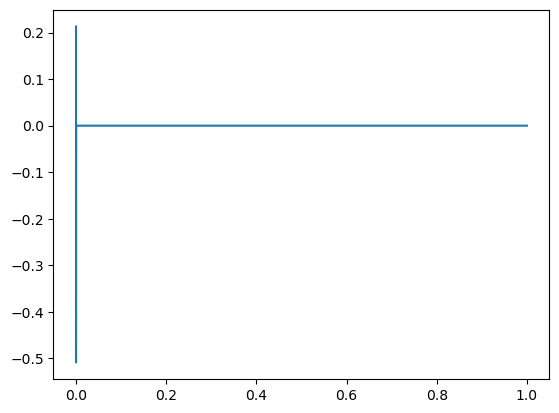

In [16]:
plt.plot(sol.t, sol.y[6,:])


In [ ]:
c = 1
print(sol.t[c], sol.y[0, c])

0.00012145416591911946 3.8640903254865e-10


In [ ]:
"""
M = bg['m'](1)
def ZerilliR(omega):
  om = omega
  R, y = EvenSolverZerilli(om) #6 seconds
  XhR, WhR, H1R, KR = y[0]+1j*y[1], y[2]+1j*y[3], y[4]+1j*y[5], y[6]+1j*y[7]

  dy = evenSystem(R, y, omega, bg, SourceTensor())
  dH1R, dKR = dy[4]+1j*dy[5], dy[6]+1j*dy[7]
  A = 2*R + 3*M
  B = R - 2*M

  ZR = (R/(A))*(KR + ((B)/(A))*(H1R - R*dKR))

  dZR = (KR + (B/A)*(H1R - R*dKR)) / A + ((R/A) * (dKR + (H1R - R*dKR)/A + (B/A)*(dH1R - dKR) - (2/A)*(H1R - R*dKR)))

  return ZR, dZR

"""

In [17]:
M, nuR = bg['m'](1), bg['nu'](1)

def ZerilliR(omega):
  R, y = EvenSolverZerilli(omega)
  XhR, WhR, H1R, KR = y[0]+1j*y[1], y[2]+1j*y[3], y[4] + 1j*y[5], y[6] + 1j*y[7]

  dy = evenSystem(R, y, omega, bg, SourceTensor())
  dH1R, dKR = dy[4] + 1j*dy[5], dy[6] + 1j*dy[7]

  ZR = R**2 *(2*R**2/(4*R + 6*M)) *(KR - cm.exp(nuR)*H1R)

  dZR = R**2 *(((8*R**2 - 24*M*R + 2*M) * KR + cm.exp(2*nuR) *(24*R**2 + 24*M*(R+M)) *H1R)/(4*R + 6*M)**2)

  return ZR, dZR

In [18]:
ZerilliR(0.5)

(np.complex128(-2.418978155126001e-19+0j),
 np.complex128(-7.719448895180406e-19+0j))

In [20]:
ZerilliR(0.5)

(np.complex128(2.17286477186244e-15+0j),
 np.complex128(7.956775837713412e-14+0j))

## Outer problem - Zerilli

In [6]:
M = 0.2

In [ ]:
def Zpot(r):
  def F(r):
    return 1-(2*M/r)
  pot = (2*F(r)/(r**3 *(2*r + 3*M)**2)) *(12*r**3 + 12*M*r**2 + 18*M**2 *r + 9*M**3)
  return pot


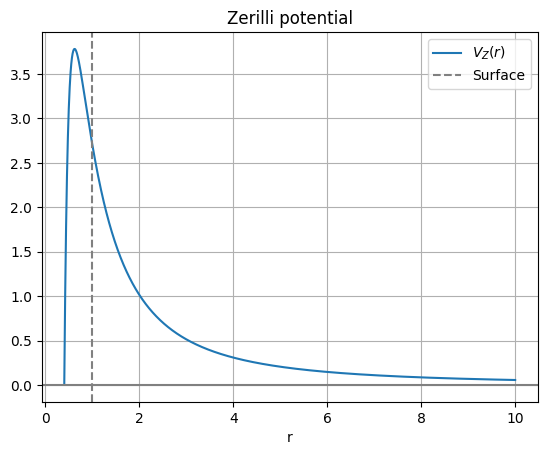

In [ ]:
rtest = np.linspace(2*M, 50*M, 2000)
plt.title('Zerilli potential')
plt.plot(rtest, Zpot(rtest), label=r'$V_{Z}(r)$')
plt.axvline(1, color='grey', linestyle='--', label = 'Surface')
plt.axhline(0, color='grey', linestyle='-')
plt.xlabel('r')
plt.grid(True)
plt.legend()

In [18]:
def Z_coeffs_l2(M, omega, order=5):

    A = {0: 1.0 + 0j}

    if order >= 1:
        A[1] = (3j)/omega - 4j*M**2*omega

    if order >= 2:
        A[2] = (12*M**2
                - 3/omega**2
                - (3j*M)/omega
                - 4j*M**3*omega
                - 8*M**4*omega**2)

    if order >= 3:
        A[3] = (M*(36
                    + 207j*M*omega
                    - 352j*M**3*omega**3
                    - 192*M**4*omega**4
                    + 128j*M**5*omega**5)
                )/(12*omega**2)

    if order >= 4:
        A[4] = (49*M**4
                - (15j*M)/(4*omega**3)
                - (51*M**2)/(8*omega**2)
                - (63j*M**3)/(8*omega)
                - 32j*M**5*omega
                - (184*M**6*omega**2)/3
                + 32j*M**7*omega**3
                + (32*M**8*omega**4)/3)

    if order >= 5:
        A[5] = (M*(-1260
                    + 1170j*M*omega
                    - 1710*M**2*omega**2
                    + 9915j*M**3*omega**3
                    + 5160*M**4*omega**4
                    - 30432j*M**5*omega**5
                    - 28160*M**6*omega**6
                    + 25600j*M**7*omega**7
                    + 10240*M**8*omega**8
                    - 2048j*M**9*omega**9)
                )/(240*omega**4)

    return {k: A[k] for k in range(0, order+1)}


def zerilli_series_and_derivative(r, M, omega, A):
    """
    Evaluate Z(r) and dZ/dr from outgoing Zerilli series
    """
    phase = np.exp(1j*omega*r) * r**(2j*M*omega)

    Z = 0.0 + 0j
    dZ = 0.0 + 0j

    for k, Ak in A.items():
        Z += Ak / r**k
        dZ += -k * Ak / r**(k+1)

    Z *= phase
    dZ = phase * (1j*omega*Z/phase + (2j*M*omega)/r * Z/phase + dZ)

    return Z, dZ

def zerilli_rhs(r, y, omega, M):
    Z, dZ = y
    f = 1.0 - 2.0*M/r

    VZ = (2*f/(r**3*(2*r + 3*M)**2)) * (
            12*r**3
            + 12*M*r**2
            + 18*M**2*r
            + 9*M**3
         )

    d2Z = -(2*M/r**2)/f * dZ - ((omega**2 - VZ)/f**2) * Z
    return [dZ, d2Z]


In [19]:
zerilli_series_and_derivative(50*M, M, 0.5, Z_coeffs_l2(M, 0.5, 4))

(np.complex128(1.0289934707001063-0.2552395038398423j),
 np.complex128(0.10621095555011018+0.47995677492443234j))

In [20]:
def integrate_zerilli_from_infinity(omega, M, r_match, r_max,
                                    order=4,
                                    rtol=1e-10,
                                    atol=1e-10,
                                    method='RK45'):

    if r_max <= 2.0*M:
        raise ValueError("r_max must satisfy r_max > 2M.")

    A = Z_coeffs_l2(M, omega, order=order)
    Z0, dZ0 = zerilli_series_and_derivative(r_max, M, omega, A)

    sol = solve_ivp(
        lambda r, y: zerilli_rhs(r, y, omega, M),
        [r_max, r_match],
        [Z0, dZ0],
        method=method,
        rtol=rtol,
        atol=atol,
        dense_output=True
    )

    if not sol.success:
        raise RuntimeError(f"Exterior Zerilli integration failed: {sol.message}")

    return sol.sol


In [21]:
def mismatch_even(profile, omega, r_match, r_max,
                   r0=1e-6,
                   order=4):

    R = profile['R']
    M = profile['M']

    # Interior → Zerilli at R^-
    Z_int, dZ_int = ZerilliR(omega)
    if abs(Z_int) < 1e-30:
      raise FloatingPointError("Z_int too small for stable log-derivative")

    # Exterior Zerilli from infinity
    ext_sol = integrate_zerilli_from_infinity(
        omega, M, r_match, r_max, order=order
    )

    Z_ext, dZ_ext = ext_sol(r_match)
    """
    # IMPORTANT: convert to tortoise derivatives
    f = 1.0 - 2.0*M/r_match
    dZ_int_star = f * dZ_int
    dZ_ext_star = f * dZ_ext
    """
    #print("Z_int =", Z_int,"dZ_int=", dZ_int,"Z_ext=", Z_ext,"dZ_ext=", dZ_ext)
    return dZ_int/Z_int - dZ_ext/Z_ext


In [23]:
r_match = r_end
r_max = 50*M
mismatch_even(profile, 0.5, r_end, r_max)

np.complex128(5.426836840264377-0.005775936197067705j)

In [22]:
from tqdm import tqdm

def scan_param_even(profile,
                    re_range,
                    im_range,
                    r_match,
                    r_max,
                    r0=1e-6,
                    order=4):

    Re = np.linspace(*re_range)
    Im = np.linspace(*im_range)

    heat = np.empty((len(Re), len(Im)))

    for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
        for j, im in enumerate(Im):
            om = re + 1j*im
            try:
                Delta = mismatch_even(profile, om,
                                      r_match, r_max,
                                      r0=r0, order=order)
                heat[i, j] = np.log10(max(1e-30, abs(Delta)))
            except Exception:
                heat[i, j] = np.nan

    return Re, Im, heat


from scipy.optimize import root

def find_qnm_even(profile,
                  omega_guess,
                  r_match,
                  r_max,
                  r0=1e-6,
                  tol=1e-10,
                  maxfev=300,
                  order=4,
                  method='lm'):

    def F(xy):
        om = xy[0] + 1j*xy[1]
        Delta = mismatch_even(profile, om,
                              r_match, r_max,
                              r0=r0, order=order)
        return np.array([Delta.real, Delta.imag], float)

    x0 = np.array([omega_guess.real, omega_guess.imag], float)

    sol = root(F, x0, method=method, tol=tol, options={'maxfev': maxfev})

    if not sol.success:
        raise RuntimeError(f"QNM mismatch solve failed: {sol.message}")

    om_star = sol.x[0] + 1j*sol.x[1]
    Delta_f = mismatch_even(profile, om_star,
                            r_match, r_max,
                            r0=r0, order=order)

    info = {
        'success': bool(sol.success),
        'message': sol.message,
        'nfev': sol.nfev,
        'qnm': om_star,
        'Delta': Delta_f,
        'abs(Delta)': abs(Delta_f)
    }

    print(f"success={info['success']} message={info['message']}")
    print(f"ω* = {om_star:.12g}  |Δ| = {abs(Delta_f):.3e}  "
          f"at r_match={r_match}, r_max={r_max:.3g}")

    return om_star, info


In [ ]:
# coarse scan
Re, Im, heat = scan_param_even(profile,re_range=(0.1, 2.5, 80),im_range=(-0.5, 0.0, 80),r_match=r_match,r_max=50*M)



Scanning Re(ω):  66%|██████▋   | 53/80 [4:28:42<2:02:12, 271.59s/it]

In [ ]:

# eyeball a minimum → choose initial guess
omega_guess = 1.1 - 0.15j

# refine
omega_qnm, info = find_qnm_even(profile,
                                omega_guess,
                                r_match=profile['R'],
                                r_max=60*profile['M'])

In [26]:
import time
t0 = time.time()
print(mismatch_even(profile, 1.0 - 0.2j, r_match, 30*M))
print("time =", time.time() - t0)


(0.8400605886881246+2.8712311375703985j)
time = 1.3379719257354736


In [29]:
import os
os.cpu_count()

24

# Optimization Overkill trial

In [ ]:
r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4

def make_bg_tables(bg, r_grid):
    return {
        'r': r_grid,
        'm': bg['m'](r_grid),
        'p': bg['p'](r_grid),
        'rho': bg['rho'](r_grid),
        'nu': bg['nu'](r_grid),
        'lam': bg['lam'](r_grid),
        'lam_p': bg['lam_p'](r_grid),
        'nu_p': bg['nu_p'](r_grid),
        'p_prime': bg['p_prime'](r_grid),
        'rho_prime': bg['rho_prime'](r_grid),
        'cs2': bg['cs2'](r_grid),
    }

def pack_bg_quantities(bg_tab):

    return np.vstack([
        bg_tab['m'],
        bg_tab['p'],
        bg_tab['rho'],
        bg_tab['nu'],
        bg_tab['lam'],
        bg_tab['lam_p'],
        bg_tab['nu_p'],
        bg_tab['p_prime'],
        bg_tab['rho_prime'],
        bg_tab['cs2'],
    ])

r_tab = np.linspace(eps, r_end, 4000)


In [20]:
eps

1e-06

In [21]:
1/eps**2

1000000000000.0

In [16]:
pack_bg_quantities(make_bg_tables(bg, r_tab))

array([[-3.77464216e-19,  1.08926851e-11,  8.66195070e-11, ...,
         1.99999688e-01,  1.99999894e-01,  1.99999991e-01],
       [ 3.26285976e-02,  3.26285908e-02,  3.26285704e-02, ...,
         8.29622681e-09,  2.82091740e-09,  2.30072403e-10],
       [ 1.80633877e-01,  1.80633858e-01,  1.80633802e-01, ...,
         9.10836336e-05,  5.31122895e-05,  1.51681916e-05],
       ...,
       [-1.89973660e-07, -5.43077586e-05, -1.08424023e-04, ...,
        -2.76741885e-05, -1.61258269e-05, -4.60166221e-06],
       [-5.26215767e-07, -1.50325538e-04, -3.00120983e-04, ...,
        -1.51916306e-01, -1.51808563e-01, -1.51687280e-01],
       [ 3.61043871e-01,  3.61145280e-01,  3.61213154e-01, ...,
         1.82166995e-04,  1.06225262e-04,  3.03366248e-05]])

In [17]:
class ZeroSource:
    __slots__ = ()
    def S01(self, r, om): return 0.0
    def S01p(self, r, om): return 0.0
    def S00(self, r, om): return 0.0
    def S0A(self, r, om): return 0.0
    def SZ(self, r, om): return 0.0
    def S0(self, r, om): return 0.0
    def S0p(self, r, om): return 0.0
    def S1(self, r, om): return 0.0
    def S1p(self, r, om): return 0.0
    def SOm(self, r, om): return 0.0

def make_source(source, r_grid, omega):

    return {
        'S01':  np.asarray([source.S01(r,  omega) for r in r_grid]),
        'S01p': np.asarray([source.S01p(r, omega) for r in r_grid]),
        'S00':  np.asarray([source.S00(r,  omega) for r in r_grid]),
        'S0A':  np.asarray([source.S0A(r,  omega) for r in r_grid]),
        'SZ':   np.asarray([source.SZ(r,   omega) for r in r_grid]),
        'S0':   np.asarray([source.S0(r,   omega) for r in r_grid]),
        'S0p':  np.asarray([source.S0p(r,  omega) for r in r_grid]),
        'S1':   np.asarray([source.S1(r,   omega) for r in r_grid]),
        'S1p':  np.asarray([source.S1p(r,  omega) for r in r_grid]),
        'SOm':  np.asarray([source.SOm(r,  omega) for r in r_grid]),
    }

def pack_source(source_tables):
    return np.vstack([source_tables[k] for k in ('S01','S01p','S00','S0A','SZ','S0','S0p','S1','S1p','SOm')])

In [18]:
pack_source(make_source(ZeroSource(), r_tab, 0.5))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [19]:
pack_source(make_source(SourceTensor(), r_tab, 0.5))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
from numba import njit

@njit()
def interp(r, r_grid, f_grid):
    i = np.searchsorted(r_grid, r) - 1
    if i < 0:
        i = 0
    if i >= r_grid.size - 1:
        i = r_grid.size - 2

    r0 = r_grid[i]
    r1 = r_grid[i+1]
    f0 = f_grid[i]
    f1 = f_grid[i+1]

    return f0 + (f1 - f0) * (r - r0) / (r1 - r0)


In [45]:
@njit
def evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2):
    Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
    pi = cm.pi
    Xh = Xhre + 1j*Xhim
    Wh = Whre + 1j*Whim
    H1 = H1re + 1j*H1im
    K = Kre + 1j*Kim

    m = interp(r, r_grid, bg_tab[0])
    p = interp(r, r_grid, bg_tab[1])
    rho = interp(r, r_grid, bg_tab[2])
    nu = interp(r, r_grid, bg_tab[3])
    lam = interp(r, r_grid, bg_tab[4])
    lam_p = interp(r, r_grid, bg_tab[5])
    nu_p = interp(r, r_grid, bg_tab[6])
    p_prime = interp(r, r_grid, bg_tab[7])
    rho_prime = interp(r, r_grid, bg_tab[8])
    cs2 = interp(r, r_grid, bg_tab[9])
    
    if np.all(source == 0):
        S01 = 0.0
        S01p = 0.0
        S00 = 0.0
        S0A = 0.0
        SZ = 0.0
        S0 = 0.0
        S0p = 0.0
        S1 = 0.0
        S1p = 0.0
        SOm = 0.0
    else:
        S01  = interp(r, r_grid, source[0])
        S01p = interp(r, r_grid, source[1])
        S00  = interp(r, r_grid, source[2])
        S0A  = interp(r, r_grid, source[3])
        SZ   = interp(r, r_grid, source[4])
        S0   = interp(r, r_grid, source[5])
        S0p  = interp(r, r_grid, source[6])
        S1   = interp(r, r_grid, source[7])
        S1p  = interp(r, r_grid, source[8])
        SOm  = interp(r, r_grid, source[9])

    
    #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
    Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))
    drhods = 0

    Eh = (Xh/cs2) + drhods*Sigh


    Hdenom = 3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
    H = (-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

    Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
    Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
    Vh = Vhnum2/(2*om**2 *(rho+p))

    dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
    dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
    dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
    dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm


    return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])




In [46]:
def even_wrapper(r, y, om, r_grid, bg_tab, source):
    return evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2)

def EvenSolver_zoom(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol

def EvenSolverNumbaZerilli(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t[-1], sol.y[:,-1]




In [47]:
EvenSolverNumbaZerilli(0.5, r_tab, bg)

(np.float64(0.9998999829912599),
 array([-1.03914965e-19,  0.00000000e+00, -3.83072672e-14,  0.00000000e+00,
        -4.53184065e-18,  0.00000000e+00, -2.26271114e-18,  0.00000000e+00]))

In [33]:
#RK45
EvenSolverNumbaZerilli(0.5, r_tab, bg)

(np.float64(0.9998999829912599),
 array([1.80785297e-15, 0.00000000e+00, 6.87660323e-10, 0.00000000e+00,
        1.66793899e-13, 0.00000000e+00, 1.04070448e-13, 0.00000000e+00]))

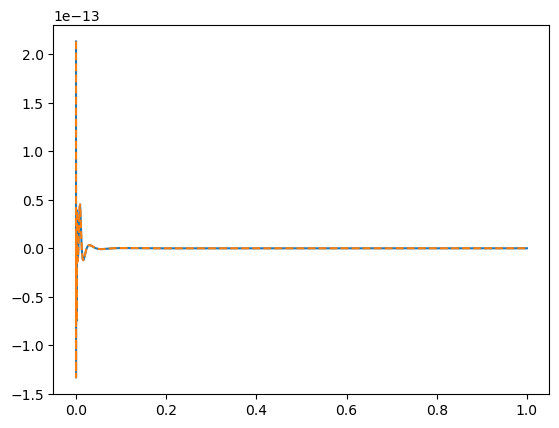

In [35]:
sol_trial =  EvenSolver_zoom(0.5, r_tab, bg)
(sol_trial.t).shape

sol_old = EvenSolver(0.5,1e-6)
plt.plot(sol_old.t, sol_old.y[6,:])
plt.plot(sol_trial.t, sol_trial.y[6,:], linestyle='--')

del sol_old, sol_trial

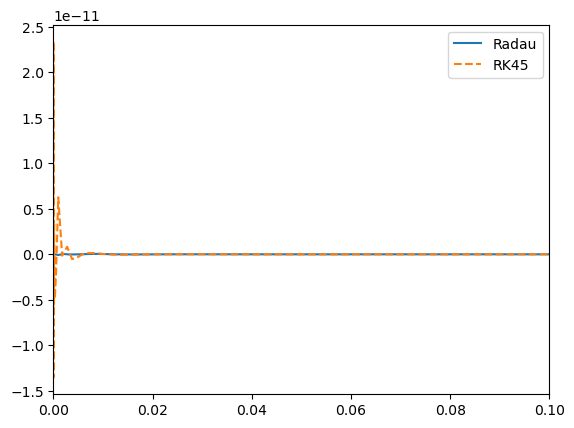

In [53]:
#RK45 v Radau comparison
sol_trial =  EvenSolver_zoom(0.5, r_tab, bg)
(sol_trial.t).shape

sol_old = EvenSolver(0.5,1e-6)
plt.plot(sol_old.t, sol_old.y[6,:], label='Radau')
plt.plot(sol_trial.t, sol_trial.y[6,:], linestyle='--', label='RK45')
plt.legend()
plt.xlim(0,0.1)
del sol_old, sol_trial

In [ ]:
M, nuR = bg['m'](1), bg['nu'](1)

def ZerilliR(omega, r_tab, bg_tab):
  R, y = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)
  XhR, WhR, H1R, KR = y[0]+1j*y[1], y[2]+1j*y[3], y[4] + 1j*y[5], y[6] + 1j*y[7]
  source_tab = make_source(SourceTensor(), r_tab, omega)
  sourcearray = pack_source(source_tab)
  bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_tab))
  dy = evenSystem_zoom(R, y, omega, r_tab, bgarray, sourcearray)
  dH1R, dKR = dy[4] + 1j*dy[5], dy[6] + 1j*dy[7]

  ZR = R**2 *(2*R**2/(4*R + 6*M)) *(KR - cm.exp(nuR)*H1R)

  dZR = R**2 *(((8*R**2 - 24*M*R + 2*M) * KR + cm.exp(2*nuR) *(24*R**2 + 24*M*(R+M)) *H1R)/(4*R + 6*M)**2)

  return ZR, dZR

In [49]:
ZerilliR(0.5, r_tab, bg)

(np.complex128(1.7547916691199484e-19+0j),
 np.complex128(-2.0963137224163606e-18+0j))

In [50]:
def mismatch_even(profile, omega, r_tab, bg, r_match, r_max,
                   r0=1e-6,
                   order=4):

    R = profile['R']
    M = profile['M']

    # Interior → Zerilli at R^-
    Z_int, dZ_int = ZerilliR(omega, r_tab, bg)
    if abs(Z_int) < 1e-30:
      raise FloatingPointError("Z_int too small for stable log-derivative")

    # Exterior Zerilli from infinity
    ext_sol = integrate_zerilli_from_infinity(
        omega, M, r_match, r_max, order=order
    )

    Z_ext, dZ_ext = ext_sol(r_match)


    return dZ_int/Z_int - dZ_ext/Z_ext


In [51]:
from tqdm import tqdm

def scan_param_even(profile,
                    re_range,
                    im_range,
                    r_tab,
                    bg,
                    r_match,
                    r_max,
                    r0=1e-6,
                    order=4):

    Re = np.linspace(*re_range)
    Im = np.linspace(*im_range)

    heat = np.empty((len(Re), len(Im)))

    for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
        for j, im in enumerate(Im):
            om = re + 1j*im
            try:
                Delta = mismatch_even(profile, om, r_tab, bg,
                                      r_match, r_max,
                                      r0=r0, order=order)
                heat[i, j] = np.log10(max(1e-30, abs(Delta)))
            except Exception:
                heat[i, j] = np.nan

    return Re, Im, heat


from scipy.optimize import root




Scanning Re(ω): 100%|██████████| 80/80 [1:54:17<00:00, 85.72s/it] 


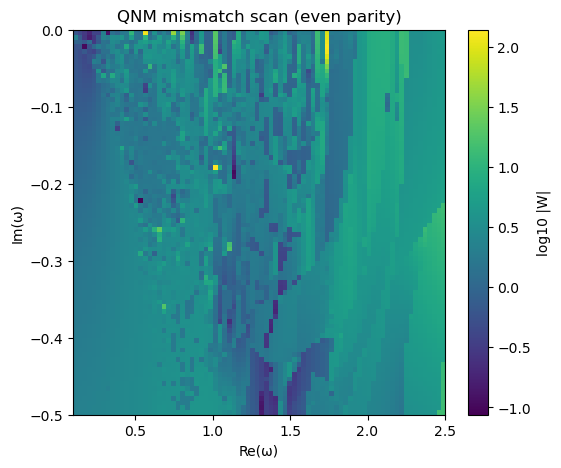

In [126]:
Re, Im, heat = scan_param_even(profile,re_range=(0.1, 2.5, 80),im_range=(-0.5, 0.0, 80), r_tab=r_tab, bg=bg, r_match=r_match,r_max=50*M)
plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('QNM mismatch scan (even parity)')
plt.show()

In [23]:
150*150

22500

Scanning Re(ω): 100%|██████████| 150/150 [2:36:22<00:00, 62.55s/it] 


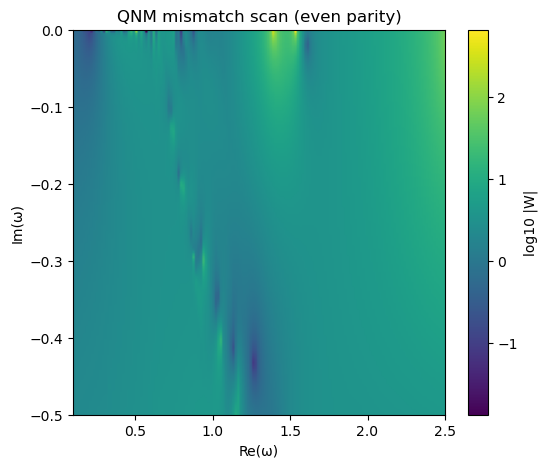

In [59]:
#Higher resolution scan
r_match = r_end
Re, Im, heat = scan_param_even(profile,re_range=(0.1, 2.5, 150),im_range=(-0.5, 0.0, 150), r_tab=r_tab, bg=bg, r_match=r_match,r_max=50*M)
plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('QNM mismatch scan (even parity)')
plt.show()

In [ ]:
#Small Imaginary part scan
r_match = r_end
Re, Im, heat = scan_param_even(profile,re_range=(0.1, 2.5, 80),im_range=(-0.5, 0.0, 80), r_tab=r_tab, bg=bg, r_match=r_match,r_max=50*M)
plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('QNM mismatch scan (even parity)')
plt.show()

Scanning Re(ω): 100%|██████████| 80/80 [1:08:13<00:00, 51.17s/it]


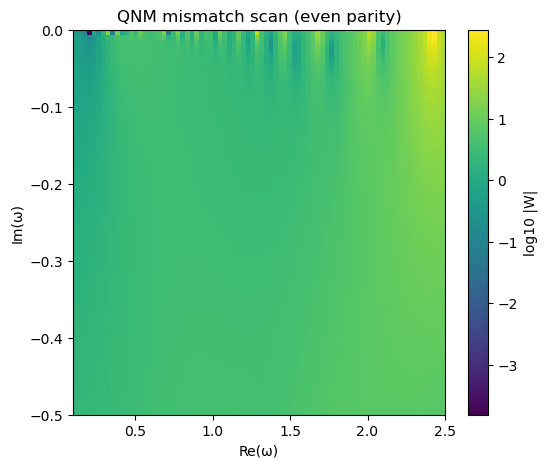

In [39]:
#Without suppression
r_match = r_end
Re, Im, heat = scan_param_even(profile,re_range=(0.1, 2.5, 80),im_range=(-0.5, 0.0, 80), r_tab=r_tab, bg=bg, r_match=r_match,r_max=50*M)
plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re[0], Re[-1], Im[0], Im[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='log10 |W|')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('QNM mismatch scan (even parity)')
plt.show()

In [52]:
def find_qnm_even(profile,
                  omega_guess,
                  r_match,
                  r_max,
                  r_tab,
                  bg,
                  r0=1e-6,
                  tol=1e-10,
                  maxfev=300,
                  order=4,
                  method='lm'):

    def F(xy):
        om = xy[0] + 1j*xy[1]
        Delta = mismatch_even(profile, om, r_tab, bg, r_match, r_max, r0=r0, order=order)
        return np.array([Delta.real, Delta.imag], float)

    x0 = np.array([omega_guess.real, omega_guess.imag], float)

    sol = root(F, x0, method=method, tol=tol, options={'maxiter': maxfev})

    if not sol.success:
        raise RuntimeError(f"QNM mismatch solve failed: {sol.message}")

    om_star = sol.x[0] + 1j*sol.x[1]
    Delta_f = mismatch_even(profile, om_star, r_tab, bg, r_match, r_max, r0=r0, order=order)

    info = {
        'success': bool(sol.success),
        'message': sol.message,
        'nfev': sol.nfev,
        'qnm': om_star,
        'Delta': Delta_f,
        'abs(Delta)': abs(Delta_f)
    }

    print(f"success={info['success']} message={info['message']}")
    print(f"ω* = {om_star:.12g}  |Δ| = {abs(Delta_f):.3e}  "
          f"at r_match={r_match}, r_max={r_max:.3g}")

    return om_star, info

In [50]:
omega_trial = 1.5-0.05j
omega_qnm, info = find_qnm_even(profile,
                                omega_trial,
                                r_match=r_end,
                                r_max=50*profile['M'],
                                r_tab=r_tab,
                                bg=bg)

success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 1.26609769398-0.433388128566j  |Δ| = 5.386e-11  at r_match=0.9998999829912599, r_max=10


In [51]:
qnms=[]
for i in (r_match-1e-3, r_match, r_match+1e-3):
    for j in (50*M -1, 50*M, 50*M +1):
        print("r_match =", i, "r_max =", j)
        omega_qnm, info = find_qnm_even(profile,
                                        omega_trial,
                                        r_match=i,
                                        r_max=j,
                                        r_tab=r_tab,
                                        bg=bg)
        qnms.append(omega_qnm)


r_match = 0.9988999829912599 r_max = 8.999999999987425
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 1.26853272143-0.433014379387j  |Δ| = 4.867e-11  at r_match=0.9988999829912599, r_max=9
r_match = 0.9988999829912599 r_max = 9.999999999987425
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 1.26639019397-0.433143148516j  |Δ| = 3.122e-11  at r_match=0.9988999829912599, r_max=10
r_match = 0.9988999829912599 r_max = 10.999999999987425
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 1.26920822198-0.434623998672j  |Δ| = 7.779e-11  at r_match=0.9988999829912599, r_max=11
r_match = 0.9998999829912599 r_max = 8.999999999987425
success=True message=The relative error between two consecutive iterates is at most 0.000000
ω* = 1.26825037991-0.433272914041j  |Δ| = 7.185e-11  at r_match=0.9998999829912599, r_max=9
r_match = 0.9998999829912599 r_max = 

In [52]:
qnms

[np.complex128(1.2685327214266555-0.43301437938699694j),
 np.complex128(1.266390193974211-0.4331431485157453j),
 np.complex128(1.2692082219771237-0.43462399867161405j),
 np.complex128(1.2682503799103428-0.43327291404079493j),
 np.complex128(1.2660976939872244-0.4333881285556113j),
 np.complex128(1.268921745166846-0.43489665703728225j),
 np.complex128(1.267969162952271-0.43353091394316084j),
 np.complex128(1.2658064266262201-0.43363251293915156j),
 np.complex128(1.2686363015663733-0.4351687730141169j)]

In [53]:
sol_trial = EvenSolver_zoom(1.2686363015663733-0.4351687730141169j, r_tab, bg)

In [58]:
sol_trial.y[5,:]

array([ 0.00000000e+00,  1.53804072e-14,  8.39181109e-14, ...,
       -2.15164014e-21, -2.14337634e-21, -2.14030970e-21])

In [59]:
del sol_trial

In [62]:
0.01/100

0.0001

f- mode scan

In [53]:
def mismatch_even_wronskian(profile, omega, r_tab, bg,
                            r_match, r_max,
                            r0=1e-6, order=4):
    """
    Wronskian-type matching condition.
    Sensitive to f-, p-, and w-modes.
    """

    M = profile['M']

    # Interior → Zerilli at R^-
    Z_int, dZ_int = ZerilliR(omega, r_tab, bg)

    # Exterior Zerilli from infinity
    ext_sol = integrate_zerilli_from_infinity(
        omega, M, r_match, r_max, order=order
    )
    Z_ext, dZ_ext = ext_sol(r_match)

    # Proper matching condition
    return Z_int * dZ_ext - dZ_int * Z_ext


def scan_param_even_fluid(profile,
                          re_range,
                          im_value,     # FIXED small Im
                          r_tab,
                          bg,
                          r_match,
                          r_max,
                          r0=1e-6,
                          order=4):

    Re = np.linspace(*re_range)
    heat = np.empty(len(Re))

    for i, re in enumerate(tqdm(Re, desc="Scanning Re(ω)")):
        om = re + 1j * im_value
        try:
            Delta = mismatch_even_wronskian( profile, om, r_tab, bg, r_match, r_max, r0=r0, order=order)
            heat[i] = np.log10(abs(Delta)**2 + 1e-40)
        except Exception:
            heat[i] = np.nan

    return Re, heat


In [64]:
Re, heat = scan_param_even_fluid(profile, re_range=(0.1, 2.5, 3000), im_value= -1e-3, r_tab=r_tab,   bg=bg,r_match=r_match, r_max=50*M)

                                

Scanning Re(ω): 100%|██████████| 3000/3000 [1:00:57<00:00,  1.22s/it]


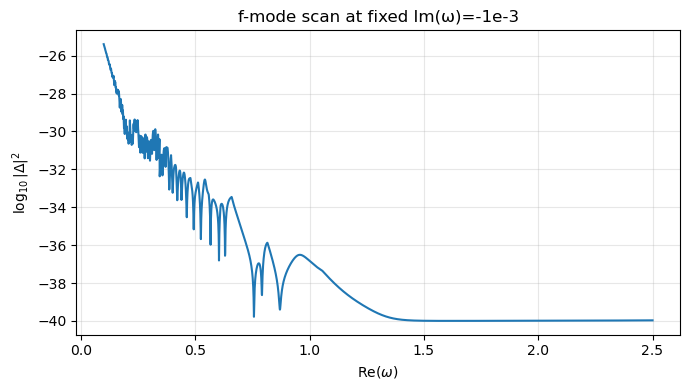

In [68]:
plt.figure(figsize=(7, 4))

plt.plot(Re, heat, lw=1.5)

plt.xlabel(r"$\mathrm{Re}(\omega)$")
plt.ylabel(r"$\log_{10}|\Delta|^2$")
plt.title("f-mode scan at fixed Im(ω)=-1e-3")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

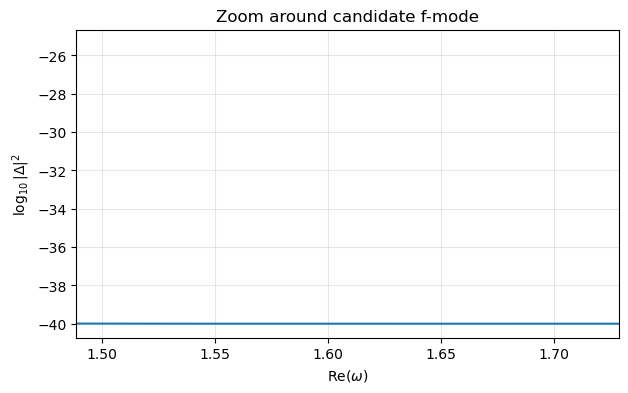

In [69]:
idx = np.nanargmin(heat)

Re0 = Re[idx]
width = 0.05 * (Re.max() - Re.min())

plt.figure(figsize=(7, 4))
plt.plot(Re, heat)
plt.xlim(Re0 - width, Re0 + width)
plt.xlabel(r"$\mathrm{Re}(\omega)$")
plt.ylabel(r"$\log_{10}|\Delta|^2$")
plt.title("Zoom around candidate f-mode")
plt.grid(alpha=0.3)
plt.show()


In [75]:
from scipy.signal import find_peaks

mask = (Re > 0.6) & (Re < 1.2)

Re_s = Re[mask]
heat_s = heat[mask]
peaks, props = find_peaks(
    -heat_s,
    prominence=0.5,     # tune this if needed
    distance=20         # avoids clustering
)

print("Candidate Re(ω):")
for i, p in enumerate(peaks):
    print(
        f"{i}: Re = {Re_s[p]:.6f}, "
        f"prominence = {props['prominences'][i]:.3f}"
    )



Candidate Re(ω):
0: Re = 0.604168, prominence = 2.093
1: Re = 0.630577, prominence = 2.742
2: Re = 0.757019, prominence = 3.907
3: Re = 0.792231, prominence = 1.679
4: Re = 0.870657, prominence = 2.895


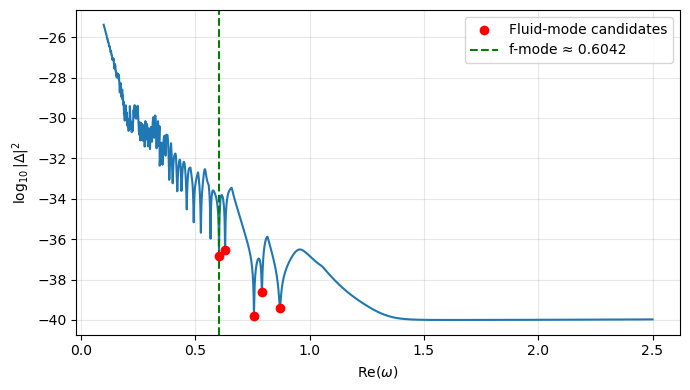

In [77]:
plt.figure(figsize=(7,4))
plt.plot(Re, heat, lw=1.5)

f_mode_index = peaks[0]
omega_f = Re_s[f_mode_index]

plt.scatter(
    Re_s[peaks],
    heat_s[peaks],
    color='red',
    zorder=5,
    label="Fluid-mode candidates"
)

plt.axvline(
    omega_f,
    color='green',
    ls='--',
    label=f"f-mode ≈ {omega_f:.4f}"
)

plt.xlabel(r"$\mathrm{Re}(\omega)$")
plt.ylabel(r"$\log_{10}|\Delta|^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [78]:
np.sqrt(0.2)

np.float64(0.4472135954999579)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm


def scan_fluid_modes_1D(
    profile,
    re_range,
    im_values,
    r_tab,
    bg,
    r_match,
    r_max,
    r0=1e-6,
    order=4,
    re_mask=(0.6, 1.2),
    prominence=0.8,
    min_distance=20,
):
    """
    Scan for f- and p-modes using 1D Re(ω) scans at fixed Im(ω).

    Returns a dictionary keyed by Im(ω), each containing:
      - Re array
      - heat array
      - candidate frequencies
    """

    results = {}

    Re = np.linspace(*re_range)

    for im in im_values:
        print(f"\nScanning fixed Im(ω) = {im:.2e}")

        heat = np.empty_like(Re)

        # --- main scan ---
        for i, re in enumerate(tqdm(Re, desc="Re-scan")):
            omega = re + 1j * im
            try:
                Delta = mismatch_even_wronskian(
                    profile, omega, r_tab, bg,
                    r_match, r_max,
                    r0=r0, order=order
                )
                heat[i] = np.log10(abs(Delta)**2 + 1e-40)
            except Exception:
                heat[i] = np.nan

        # --- physical masking ---
        mask = (Re > re_mask[0]) & (Re < re_mask[1])
        Re_s = Re[mask]
        heat_s = heat[mask]

        # --- find local minima (fluid modes) ---
        peaks, props = find_peaks(
            -heat_s,
            prominence=prominence,
            distance=min_distance
        )

        mode_freqs = Re_s[peaks]
        prominences = props["prominences"]

        # --- store results ---
        results[im] = {
            "Re": Re,
            "heat": heat,
            "Re_modes": mode_freqs,
            "prominences": prominences,
        }

        # --- plotting ---
        plt.figure(figsize=(7, 4))
        plt.plot(Re, heat, lw=1.5, label="Mismatch")
        plt.scatter(
            mode_freqs,
            heat_s[peaks],
            color="red",
            zorder=5,
            label="Fluid-mode candidates"
        )

        if len(mode_freqs) > 0:
            f_mode = mode_freqs[0]
            plt.axvline(
                f_mode,
                color="green",
                ls="--",
                label=f"f-mode ≈ {f_mode:.5f}"
            )

        plt.xlabel(r"$\mathrm{Re}(\omega)$")
        plt.ylabel(r"$\log_{10}|\Delta|^2$")
        plt.title(rf"Fluid-mode scan at fixed Im$(\omega)$ = {im:.1e}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # --- console summary ---
        print("Detected fluid modes:")
        for k, (w, p) in enumerate(zip(mode_freqs, prominences)):
            label = "f-mode" if k == 0 else f"p{k}"
            print(f"  {label:6s}: Re(ω) = {w:.6f}, prominence = {p:.3f}")

    return results



Scanning fixed Im(ω) = -1.00e-03


Re-scan: 100%|██████████| 3000/3000 [20:14<00:00,  2.47it/s]


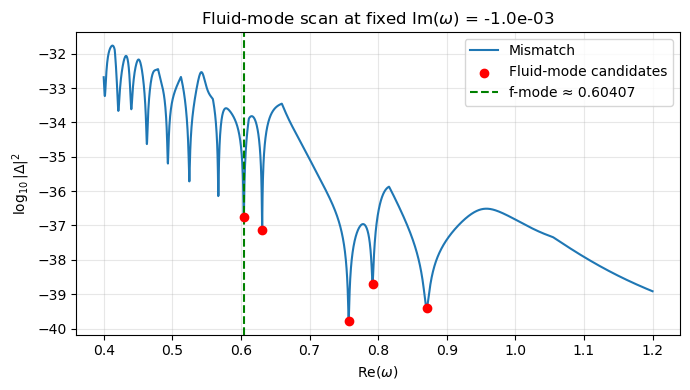

Detected fluid modes:
  f-mode: Re(ω) = 0.604068, prominence = 2.057
  p1    : Re(ω) = 0.631010, prominence = 3.305
  p2    : Re(ω) = 0.757186, prominence = 3.907
  p3    : Re(ω) = 0.791864, prominence = 1.730
  p4    : Re(ω) = 0.870557, prominence = 2.895

Scanning fixed Im(ω) = -5.00e-04


Re-scan: 100%|██████████| 3000/3000 [19:54<00:00,  2.51it/s]


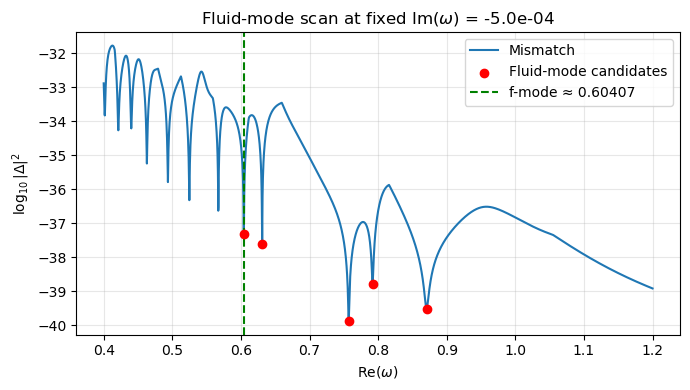

Detected fluid modes:
  f-mode: Re(ω) = 0.604068, prominence = 2.610
  p1    : Re(ω) = 0.631010, prominence = 3.786
  p2    : Re(ω) = 0.757186, prominence = 4.001
  p3    : Re(ω) = 0.791864, prominence = 1.822
  p4    : Re(ω) = 0.870557, prominence = 3.007

Scanning fixed Im(ω) = -2.00e-04


Re-scan: 100%|██████████| 3000/3000 [19:51<00:00,  2.52it/s]


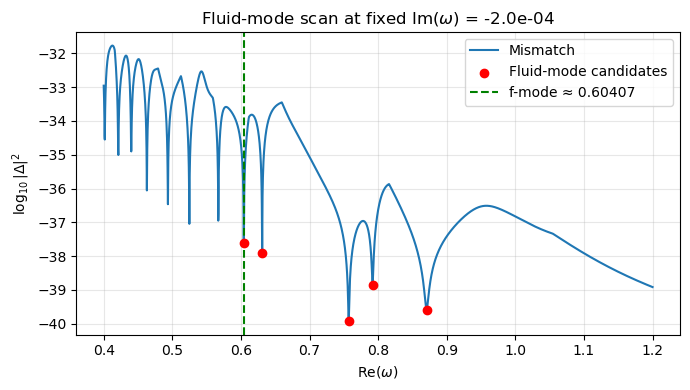

Detected fluid modes:
  f-mode: Re(ω) = 0.604068, prominence = 2.926
  p1    : Re(ω) = 0.631010, prominence = 4.082
  p2    : Re(ω) = 0.757186, prominence = 4.047
  p3    : Re(ω) = 0.791864, prominence = 1.882
  p4    : Re(ω) = 0.870557, prominence = 3.078


In [81]:
results = scan_fluid_modes_1D(
    profile=profile,
    re_range=(0.4, 1.2, 3000),
    im_values=[-1e-3, -5e-4, -2e-4],
    r_tab=r_tab,
    bg=bg,
    r_match=r_match,
    r_max=50*M,
    prominence=0.8,
)


In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm


def scan_fluid_modes_rmatch(
    profile,
    re_range,
    im_fixed,
    r_match_values,
    r_tab,
    bg,
    r_max,
    r0=1e-6,
    order=4,
    re_mask=(0.6, 1.2),
    prominence=0.8,
    min_distance=20,
):
    """
    Scan fluid modes while varying the matching radius r_match.

    For each r_match:
      - scan Re(ω) at fixed Im(ω)
      - identify local minima using find_peaks
      - plot and print candidate modes
    """

    Re = np.linspace(*re_range)
    results = {}

    for r_match in r_match_values:
        print(f"\nScanning with r_match = {r_match:.5f}")

        heat = np.empty_like(Re)

        # --- Re-scan ---
        for i, re in enumerate(tqdm(Re, desc="Re-scan")):
            omega = re + 1j * im_fixed
            try:
                Delta = mismatch_even_wronskian(
                    profile, omega, r_tab, bg,
                    r_match, r_max,
                    r0=r0, order=order
                )
                heat[i] = np.log10(abs(Delta)**2 + 1e-40)
            except Exception:
                heat[i] = np.nan

        # --- mask physical region ---
        mask = (Re > re_mask[0]) & (Re < re_mask[1])
        Re_s = Re[mask]
        heat_s = heat[mask]

        # --- detect fluid-mode candidates ---
        peaks, props = find_peaks(
            -heat_s,
            prominence=prominence,
            distance=min_distance
        )

        mode_freqs = Re_s[peaks]
        prominences = props["prominences"]

        results[r_match] = {
            "Re": Re,
            "heat": heat,
            "Re_modes": mode_freqs,
            "prominences": prominences,
        }

        # --- plot ---
        plt.figure(figsize=(7, 4))
        plt.plot(Re, heat, lw=1.5, label="Mismatch")
        plt.scatter(
            mode_freqs,
            heat_s[peaks],
            color="red",
            zorder=5,
            label="Fluid-mode candidates"
        )

        if len(mode_freqs) > 0:
            f_mode = mode_freqs[0]
            plt.axvline(
                f_mode,
                color="green",
                ls="--",
                label=f"Lowest candidate ≈ {f_mode:.5f}"
            )

        plt.xlabel(r"$\mathrm{Re}(\omega)$")
        plt.ylabel(r"$\log_{10}|\Delta|^2$")
        plt.title(
            rf"Fluid-mode scan at fixed Im$(\omega)$={im_fixed:.1e}, "
            rf"$r_{{match}}$={r_match:.3f}"
        )
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # --- console summary ---
        print("Detected candidates:")
        for k, (w, p) in enumerate(zip(mode_freqs, prominences)):
            label = "lowest" if k == 0 else f"higher-{k}"
            print(f"  {label:8s}: Re(ω) = {w:.6f}, prominence = {p:.3f}")

    return results



Scanning with r_match = 0.89991


Re-scan: 100%|██████████| 3000/3000 [21:18<00:00,  2.35it/s]


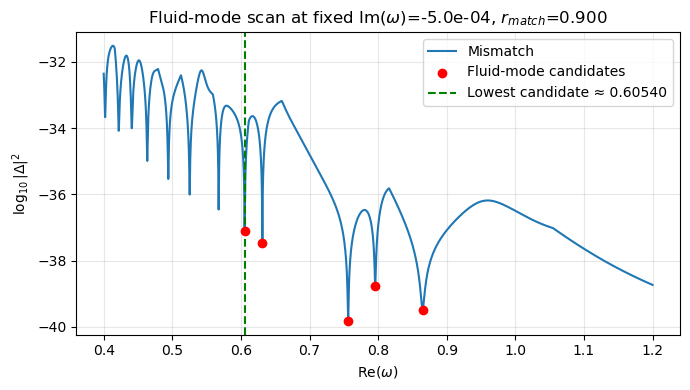

Detected candidates:
  lowest  : Re(ω) = 0.605402, prominence = 2.913
  higher-1: Re(ω) = 0.631277, prominence = 3.827
  higher-2: Re(ω) = 0.756385, prominence = 4.007
  higher-3: Re(ω) = 0.795865, prominence = 2.285
  higher-4: Re(ω) = 0.864955, prominence = 3.303

Scanning with r_match = 0.93991


Re-scan: 100%|██████████| 3000/3000 [19:51<00:00,  2.52it/s]


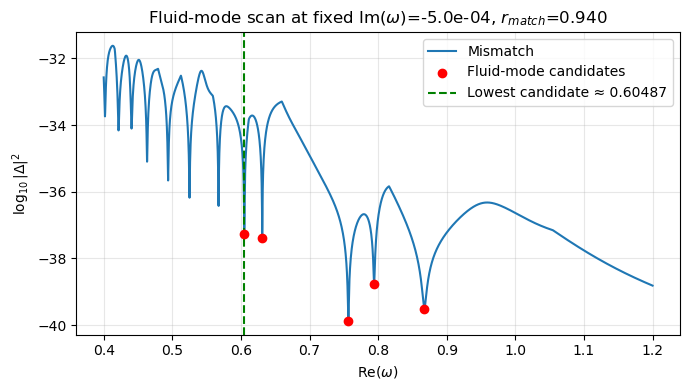

Detected candidates:
  lowest  : Re(ω) = 0.604868, prominence = 2.860
  higher-1: Re(ω) = 0.631010, prominence = 3.669
  higher-2: Re(ω) = 0.756652, prominence = 4.037
  higher-3: Re(ω) = 0.794265, prominence = 2.091
  higher-4: Re(ω) = 0.867356, prominence = 3.185

Scanning with r_match = 0.96990


Re-scan: 100%|██████████| 3000/3000 [19:45<00:00,  2.53it/s]


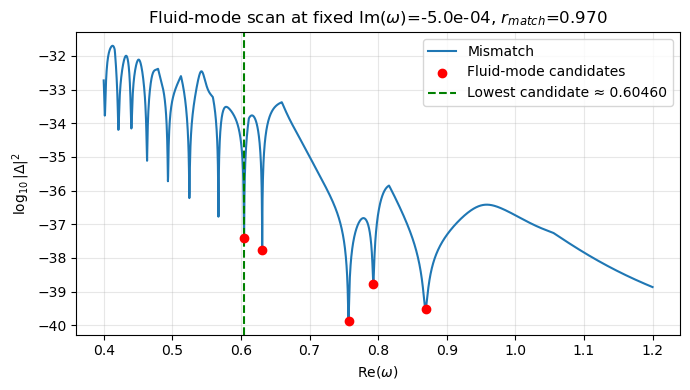

Detected candidates:
  lowest  : Re(ω) = 0.604602, prominence = 2.851
  higher-1: Re(ω) = 0.631010, prominence = 3.994
  higher-2: Re(ω) = 0.756919, prominence = 4.020
  higher-3: Re(ω) = 0.792931, prominence = 1.955
  higher-4: Re(ω) = 0.869223, prominence = 3.094

Scanning with r_match = 0.99990


Re-scan: 100%|██████████| 3000/3000 [23:29<00:00,  2.13it/s]


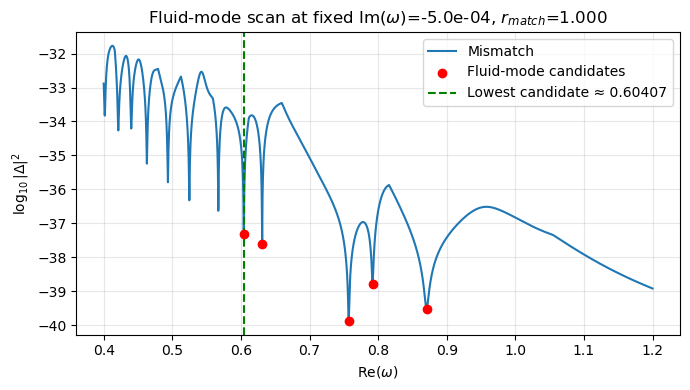

Detected candidates:
  lowest  : Re(ω) = 0.604068, prominence = 2.610
  higher-1: Re(ω) = 0.631010, prominence = 3.786
  higher-2: Re(ω) = 0.757186, prominence = 4.001
  higher-3: Re(ω) = 0.791864, prominence = 1.822
  higher-4: Re(ω) = 0.870557, prominence = 3.007


In [84]:


results_rmatch = scan_fluid_modes_rmatch(
    profile=profile,
    re_range=(0.4, 1.2, 3000),
    im_fixed=-5e-4,
    r_match_values=[0.90*r_end, 0.94*r_end, 0.97*r_end, r_end],
    r_tab=r_tab,
    bg=bg,
    r_max=50*M,
    prominence=0.8,
)


In [85]:
results_rmatch

{np.float64(0.8999099846921339): {'Re': array([0.4       , 0.40026676, 0.40053351, ..., 1.19946649, 1.19973324,
         1.2       ]),
  'heat': array([-32.35742395, -32.47514703, -32.60566683, ..., -38.73137841,
         -38.73379705, -38.73621361]),
  'Re_modes': array([0.6054018 , 0.63127709, 0.75638546, 0.79586529, 0.86495498]),
  'prominences': array([2.91282418, 3.82682206, 4.0067957 , 2.28483103, 3.30304586])},
 np.float64(0.9399059840117843): {'Re': array([0.4       , 0.40026676, 0.40053351, ..., 1.19946649, 1.19973324,
         1.2       ]),
  'heat': array([-32.5717208 , -32.70089418, -32.8455616 , ..., -38.80877149,
         -38.81109358, -38.81341359]),
  'Re_modes': array([0.60486829, 0.63101034, 0.75665222, 0.79426475, 0.86735579]),
  'prominences': array([2.85955314, 3.66929204, 4.0372224 , 2.09062378, 3.18518204])},
 np.float64(0.9699029835015222): {'Re': array([0.4       , 0.40026676, 0.40053351, ..., 1.19946649, 1.19973324,
         1.2       ]),
  'heat': array([-32.

In [86]:
import numpy as np
import matplotlib.pyplot as plt


def plot_mode_drift_vs_rmatch(results_rmatch, rmatch_ref):
    """
    Plot how Re(ω) of each detected mode shifts as r_match is varied,
    relative to a reference r_match.

    Parameters
    ----------
    results_rmatch : dict
        Output of scan_fluid_modes_rmatch
    rmatch_ref : float
        Reference r_match value (must be a key in results_rmatch)
    """

    # --- reference modes ---
    ref_modes = results_rmatch[rmatch_ref]["Re_modes"]

    r_matches = np.array(sorted(results_rmatch.keys()))

    plt.figure(figsize=(7, 4))

    for mode_idx in range(len(ref_modes)):
        deltas = []

        for r in r_matches:
            modes = results_rmatch[r]["Re_modes"]

            # Guard: skip if this r_match didn't detect this mode index
            if mode_idx >= len(modes):
                deltas.append(np.nan)
            else:
                deltas.append(modes[mode_idx] - ref_modes[mode_idx])

        deltas = np.array(deltas)

        label = "f-mode" if mode_idx == 0 else f"p{mode_idx}"
        plt.plot(
            r_matches,
            deltas,
            marker="o",
            lw=1.5,
            label=label
        )

    plt.axhline(0.0, color="black", ls="--", lw=1)

    plt.xlabel(r"$r_{\mathrm{match}}$")
    plt.ylabel(r"$\Delta\,\mathrm{Re}(\omega)$")
    plt.title("Drift of mode frequencies with matching radius")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


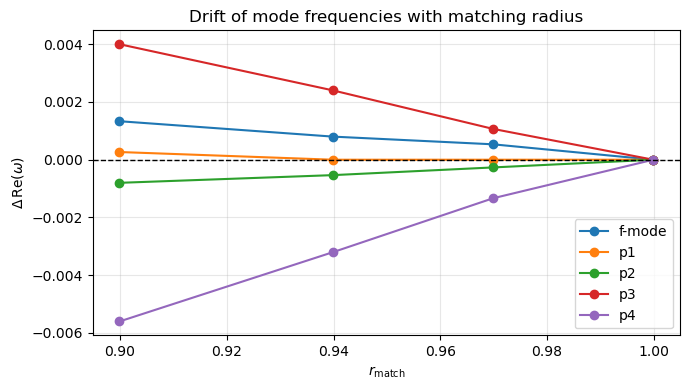

In [87]:
plot_mode_drift_vs_rmatch(results_rmatch, r_end)

In [88]:
np.savez("fluid_mode_results.npz", results=results, results_rmatch=results_rmatch)

In [29]:
import numpy as np
from scipy.optimize import minimize_scalar


def extract_imag_part(
    profile,
    omega_re,
    im_bracket,
    r_tab,
    bg,
    r_match,
    r_max,
    r0=1e-6,
    order=4,
):
    """
    Given a fixed Re(ω), find Im(ω) < 0 by minimizing |Wronskian|^2.

    Parameters
    ----------
    omega_re : float
        Real part of the mode frequency (already identified).
    im_bracket : tuple
        (im_min, im_max) with im_min < im_max < 0.
        Example: (-1e-2, -1e-6)

    Returns
    -------
    omega : complex
        Final complex QNM frequency.
    result : OptimizeResult
        Full scipy result object.
    """

    def objective(im):
        omega = omega_re + 1j * im
        Delta = mismatch_even_wronskian(
            profile, omega, r_tab, bg,
            r_match, r_max,
            r0=r0, order=order
        )
        return abs(Delta)**2

    result = minimize_scalar(
        objective,
        bracket=im_bracket,
        method="brent",
        options={"xtol": 1e-12}
    )

    omega_final = omega_re + 1j * result.x
    return omega_final, result


In [32]:
omega_re_f = 0.60407   # from your scan

omega_f, info = extract_imag_part(
    profile=profile,
    omega_re=omega_re_f,
    im_bracket=(-1e-2, -1e-6),
    r_tab=r_tab,
    bg=bg,
    r_match=r_end,
    r_max=50*M,
)

print("f-mode QNM:")
print("  ω =", omega_f)
print("  |Δ|² at minimum =", info.fun)


f-mode QNM:
  ω = (0.60407-0.00015055515963224478j)
  |Δ|² at minimum = 2.2356584264313016e-38


In [40]:
fmodeqnm = 0.60407-0.00015055515963224478j

In [42]:
fmodeqnm*M

np.complex128(0.12081399999984808-3.0111031926411097e-05j)

In [46]:
1/(np.abs(fmodeqnm.imag)) #damping time

np.float64(6642.083887677188)

In [33]:
omega_real_extracted = [0.604068, 0.631010, 0.757186, 0.791864, 0.870557]
omega_modes = []

for omega_re in omega_real_extracted:
    omega_mode, info = extract_imag_part(
        profile=profile,
        omega_re=omega_re,
        im_bracket=(-1e-2, -1e-6),
        r_tab=r_tab,
        bg=bg,
        r_match=r_end,
        r_max=50*M,
    )
    omega_modes.append(omega_mode)
    print(f"Mode Re(ω)={omega_re:.6f} → ω={omega_mode}, |Δ|²={info.fun:.3e}")

Mode Re(ω)=0.604068 → ω=(0.604068-0.00015057256047320202j), |Δ|²=2.309e-38
Mode Re(ω)=0.631010 → ω=(0.63101-7.85786170631048e-05j), |Δ|²=1.129e-38
Mode Re(ω)=0.757186 → ω=(0.757186+0.0006339486242847073j), |Δ|²=5.510e-42
Mode Re(ω)=0.791864 → ω=(0.791864+0.002906536269958696j), |Δ|²=1.928e-40
Mode Re(ω)=0.870557 → ω=(0.870557+0.002017207084335026j), |Δ|²=3.315e-44


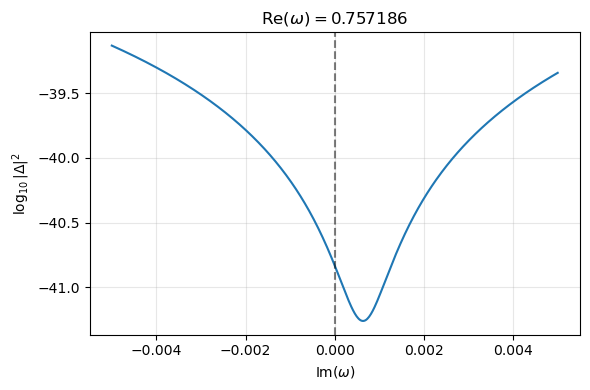

In [38]:
omega_re = 0.757186 
def objective(im):
    omega = omega_re + 1j * im
    Delta = mismatch_even_wronskian(
        profile, omega, r_tab, bg,
        r_match=r_end, r_max=50*M,
        r0=1e-6, order=4
    )
    return abs(Delta)**2

imrange = np.linspace(-0.005, +0.005, 500)
vals = []

for im in imrange:
    vals.append(objective(im))

vals = np.array(vals)

plt.figure(figsize=(6,4))
plt.plot(imrange, np.log10(vals))
plt.axvline(0, color="black", ls="--", alpha=0.5)
plt.xlabel(r"$\mathrm{Im}(\omega)$")
plt.ylabel(r"$\log_{10}|\Delta|^2$")
plt.title(rf"$\mathrm{{Re}}(\omega) = {omega_re}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


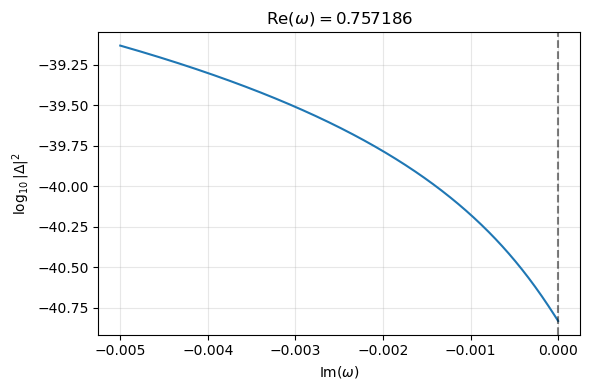

In [39]:
imrange = np.linspace(-0.005, -1e-6, 400)
omega_re = 0.757186 
def objective(im):
    omega = omega_re + 1j * im
    Delta = mismatch_even_wronskian(
        profile, omega, r_tab, bg,
        r_match=r_end, r_max=50*M,
        r0=1e-6, order=4
    )
    return abs(Delta)**2


vals = []

for im in imrange:
    vals.append(objective(im))

vals = np.array(vals)

plt.figure(figsize=(6,4))
plt.plot(imrange, np.log10(vals))
plt.axvline(0, color="black", ls="--", alpha=0.5)
plt.xlabel(r"$\mathrm{Im}(\omega)$")
plt.ylabel(r"$\log_{10}|\Delta|^2$")
plt.title(rf"$\mathrm{{Re}}(\omega) = {omega_re}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
l = 2

np.sqrt((2*l*(l-1)/(2*l+1))*(M/R**3))

np.float64(3.999999999997486e-10)

In [ ]:
omega_code = 0.60407-0.00015055515963224478j

M_code = M
M_sun_seconds = 4.925e-6
M_phys = 1.4 * M_sun_seconds

scale = M_code / M_phys
omega_phys = omega_code.real * scale
im_phys = omega_code.imag * scale

f_hz = omega_phys / (2*np.pi)
tau_s = 1.0 / abs(im_phys)

print(f"f = {f_hz:.3e} Hz, tau = {tau_s:.3e} s")


f = 2.789e+03 Hz, tau = 2.290e-01 s


In [57]:
Re_vals = np.linspace(2.5, 3.5, 200)
Im_vals = np.linspace(-1e-3, 0.0, 50)

heat = np.zeros((len(Re_vals), len(Im_vals)))

for i, re in enumerate(tqdm(Re_vals, desc="Scanning Re(ω)")):
    for j, im in enumerate(Im_vals):
        omega = re + 1j*im
        heat[i,j] = np.log10(abs(mismatch_even_wronskian(profile, omega, r_tab, bg, r_match=r_end, r_max=50*M))**2)


Scanning Re(ω): 100%|██████████| 200/200 [1:10:59<00:00, 21.30s/it]


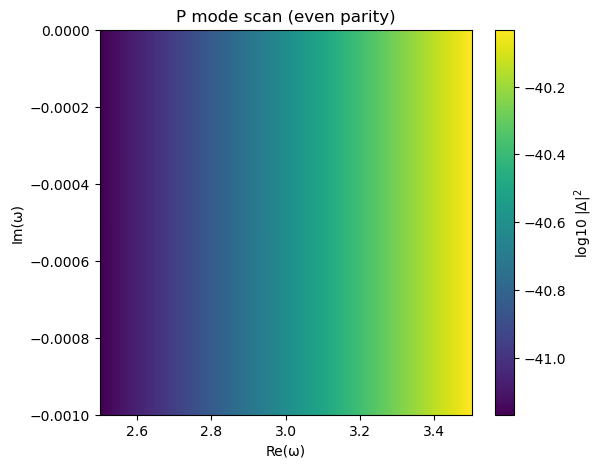

In [59]:
plt.figure(figsize=(6,5))
plt.imshow(heat.T, extent=[Re_vals[0], Re_vals[-1], Im_vals[0], Im_vals[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label=r'log10 $|\Delta|^{2}$')
plt.xlabel('Re(ω)'); plt.ylabel('Im(ω)')
plt.title('P mode scan (even parity)')
plt.show()

Text(0, 0.5, 'log10 |W|^2')

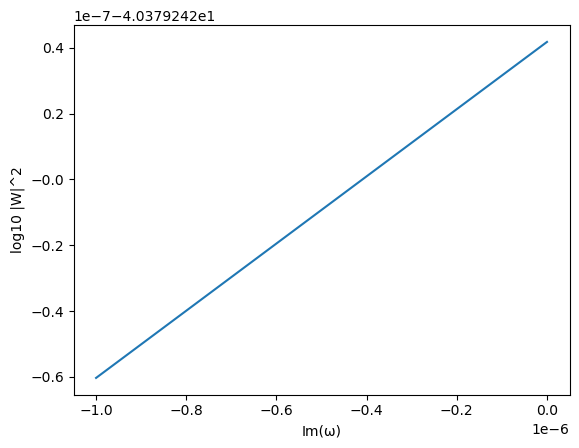

In [60]:
Im_vals = np.linspace(-1e-6, 0.0, 200)
omega_R = 3.2
def objective(im):
    omega = omega_R + 1j*im
    W = mismatch_even_wronskian(profile, omega, r_tab, bg,
                                r_match=r_end, r_max=50*M)
    return abs(W)**2

plt.plot(Im_vals, np.log10([objective(im) for im in Im_vals]))
plt.xlabel("Im(ω)")
plt.ylabel("log10 |W|^2")


In [1]:
(0.60407-0.00015055515963224478j)*0.2

(0.120814-3.011103192644896e-05j)

In [2]:
(1.2686363015663733-0.4351687730141169j)*0.2

(0.2537272603132747-0.08703375460282338j)